# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia and therefore YLDs.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import gbd_mapping
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import (
    hemoglobin_pdf_from_mean_sd,
    hemoglobin_cdf_from_mean_sd,
)

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "nigeria"
vehicle = "bouillon"

In [5]:
# Parameters
location = "nigeria"
vehicle = "rice"

In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
DRAWS = [
    f"draw_{i}" for i in range(500)
]  # NOTE: Some GBD 2021 things return 1,000 but others don't

In [8]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [9]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [10]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [11]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [12]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.081648,intervention
1,1,Male,0.081648,intervention
2,2,Female,0.108864,intervention
3,2,Male,0.108864,intervention
4,3,Female,0.132678,intervention
5,3,Male,0.132678,intervention
6,4,Female,0.153819,intervention
7,4,Male,0.153819,intervention
8,5,Female,0.164268,intervention
9,5,Male,0.164268,intervention


In [13]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [14]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.081648,intervention,0,125
1,1,Male,0.081648,intervention,0,125
2,2,Female,0.108864,intervention,0,125
3,2,Male,0.108864,intervention,0,125
4,3,Female,0.132678,intervention,0,125
5,3,Male,0.132678,intervention,0,125
6,4,Female,0.153819,intervention,0,125
7,4,Male,0.153819,intervention,0,125
8,5,Female,0.164268,intervention,0,125
9,5,Male,0.164268,intervention,0,125


In [15]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [16]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  16960.496219
                               2                  16890.884668
                               3                  15946.960379
                               4                  14017.956071
                               5                  13029.810174
                                                      ...     
Male    95.0       125.000000  1                   1846.968043
                               2                   1616.329970
                               3                   1661.447043
                               4                   1779.062429
                               5                   1896.973078
Name: value, Length: 250, dtype: float64

In [17]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [18]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

9287219.65690605

In [19]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

1228436.8594891878

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

7433910.169595711

In [21]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [22]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [23]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [24]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [25]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [26]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.to_frame()
            .assign(sex="Female")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.to_frame()
            .assign(sex="Male")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [27]:
effective_coverage_intervention = effective_coverage_intervention.reorder_levels(
    ["sex", "age_start", "age_end", "wealth_quintile", "scenario"]
)

In [28]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [29]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.081648
Name: value, dtype: float64

In [30]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distribution statistics

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [32]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        me_id=me_id, location_id=location_id, year_id=2021
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [33]:
gbd_hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
gbd_hgb_mean

draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    140.203331  139.700680  137.486100  143.738463   
       0.019178  0.076712    121.992596  122.837138  123.877519  120.604868   
       0.076712  0.500000    104.152465  104.343166  100.933682  103.672346   
       0.500000  1.000000    100.148802   99.844921   99.645127  100.145850   
       1.000000  2.000000    100.955723  100.339208  102.148597  101.234802   
       2.000000  5.000000    105.233662  104.333100  102.835176  105.304765   
       5.000000  10.000000   119.455834  112.957619  115.682929  114.256919   
       10.000000 15.000000   119.312919  106.273992  111.855854  122.097443   
       15.000000 20.000000   114.861226  117.794304  116.359602  117.648438   
       20.000000 25.000000   116.232257  117.251310  116.393998  114.894111   
       25.000000 30.000000   116.082332  114.626063  116.408492  116.811736   
       30.000000 35.000000   115.103530  115.163515  116.767807  116.269128   
       35.000000 40.000000   115.986054  113.528076  114.852973  114.288218   
       40.000000 45.000000   115.257500  117.940598  117.278455  116.853328   
       45.000000 50.000000   118.568757  119.048450  117.278407  117.835148   
       50.000000 55.000000   115.669641  121.096756  111.909301  123.510802   
       55.000000 60.000000   116.888277  111.934668  117.516013  116.335911   
       60.000000 65.000000   117.073529  120.448205  112.138824  119.361783   
       65.000000 70.000000   120.936133  131.305616  125.299052  121.720141   
       70.000000 75.000000   120.728706  120.069195  124.432953  117.908148   
       75.000000 80.000000   126.020295  126.733554  121.556975  127.985198   
       80.000000 85.000000   126.158836  126.248607  116.366249  123.473284   
       85.000000 90.000000   118.780034  118.418548  114.061451  115.310723   
       90.000000 95.000000   109.477010  104.789317  110.610979  108.944244   
       95.000000 125.000000  102.971577  100.970692   99.657313   98.358658   
Male   0.000000  0.019178    139.655000  152.652888  141.405358  135.236759   
       0.019178  0.076712    111.875330  122.227176  119.526917  118.369764   
       0.076712  0.500000     94.267052   98.335982   96.967303   98.720429   
       0.500000  1.000000    100.092403   98.678200   93.913129   99.908232   
       1.000000  2.000000    100.226883   94.470196   98.331789   95.255325   
       2.000000  5.000000    101.069093  107.942797  103.555610  102.374253   
       5.000000  10.000000   119.838610  110.970261  109.073412  112.143982   
       10.000000 15.000000   129.595152  119.217013  127.657332  129.642930   
       15.000000 20.000000   129.129905  144.220990  141.441577  142.995724   
       20.000000 25.000000   151.050744  131.461208  146.612140  132.307327   
       25.000000 30.000000   132.425569  149.591271  142.560174  135.773968   
       30.000000 35.000000   140.605288  141.846950  135.968545  160.662459   
       35.000000 40.000000   138.202586  145.354328  144.617087  133.079794   
       40.000000 45.000000   141.806468  145.535717  136.109962  148.130476   
       45.000000 50.000000   133.416092  136.101393  150.337119  141.486861   
       50.000000 55.000000   144.695059  135.210554  139.837715  139.728713   
       55.000000 60.000000   138.257682  142.365263  142.266348  143.671582   
       60.000000 65.000000   137.633530  133.990371  143.313102  140.484227   
       65.000000 70.000000   143.947810  146.078428  140.887869  134.047618   
       70.000000 75.000000   141.462864  144.115084  130.980064  145.225366   
       75.000000 80.000000   125.293565  127.635808  121.016674  127.115747   
       80.000000 85.000000   136.438006  140.853010  131.367813  139.943361   
       85.000000 90.000000   133.029351  120.328832  136.611180  126.391697   
       90.000000 95.000000   116.866389  104.222078  111.737153  113.207507   
    

In [34]:
gbd_hgb_mean.loc[("Female", 25, 30)].mean()

116.66357684455737

In [35]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                   97.093264
                               2                   99.647180
                               3                  102.658490
                               4                  103.792784
                               5                  107.778540
                                                     ...    
Male    95.0       125.000000  1                  113.444966
                               2                  115.420130
                               3                  116.087185
                               4                  116.578539
                               5                  118.793246
Name: value, Length: 250, dtype: float64

In [36]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.220707,0.219801,0.207518,0.182416,0.169557
1,Female,5.0,15.0,not_pregnant,0.222903,0.211314,0.200941,0.189893,0.174949
2,Female,15.0,30.0,not_pregnant,0.165248,0.194708,0.200403,0.223650,0.215992
3,Female,15.0,30.0,pregnant,0.229568,0.269087,0.218290,0.169175,0.113880
4,Female,30.0,50.0,not_pregnant,0.167414,0.176150,0.188366,0.214621,0.253449
5,Female,30.0,50.0,pregnant,0.247900,0.197054,0.182014,0.163763,0.209268
6,Female,50.0,125.0,not_pregnant,0.196077,0.184902,0.228885,0.192974,0.197161
7,Male,0.0,5.0,not_pregnant,0.214963,0.223211,0.203137,0.188194,0.170495
8,Male,5.0,15.0,not_pregnant,0.227134,0.211917,0.202795,0.189340,0.168813
9,Male,15.0,30.0,not_pregnant,0.194480,0.197231,0.196587,0.211924,0.199779


In [37]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.220707
                               2                  0.219801
                               3                  0.207518
                               4                  0.182416
                               5                  0.169557
                                                    ...   
Male    95.0       125.000000  1                  0.209864
                               2                  0.183658
                               3                  0.188784
                               4                  0.202148
                               5                  0.215546
Name: value, Length: 250, dtype: float64

In [38]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [39]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [40]:
hgb_mean = distribute_by_disparities(gbd_hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    140.203331  139.700680  137.486100  143.738463   
       0.019178  0.076712    121.992596  122.837138  123.877519  120.604868   
       0.076712  0.500000    104.152465  104.343166  100.933682  103.672346   
       0.500000  1.000000    100.148802   99.844921   99.645127  100.145850   
       1.000000  2.000000    100.955723  100.339208  102.148597  101.234802   
       2.000000  5.000000    105.233662  104.333100  102.835176  105.304765   
       5.000000  10.000000   119.455834  112.957619  115.682929  114.256919   
       10.000000 15.000000   119.312919  106.273992  111.855854  122.097443   
       15.000000 20.000000   114.861226  117.794304  116.359602  117.648438   
       20.000000 25.000000   116.232257  117.251310  116.393998  114.894111   
       25.000000 30.000000   116.082332  114.626063  116.408492  116.811736   
       30.000000 35.000000   115.103530  115.163515  116.767807  116.269128   
       35.000000 40.000000   115.986054  113.528076  114.852973  114.288218   
       40.000000 45.000000   115.257500  117.940598  117.278455  116.853328   
       45.000000 50.000000   118.568757  119.048450  117.278407  117.835148   
       50.000000 55.000000   115.669641  121.096756  111.909301  123.510802   
       55.000000 60.000000   116.888277  111.934668  117.516013  116.335911   
       60.000000 65.000000   117.073529  120.448205  112.138824  119.361783   
       65.000000 70.000000   120.936133  131.305616  125.299052  121.720141   
       70.000000 75.000000   120.728706  120.069195  124.432953  117.908148   
       75.000000 80.000000   126.020295  126.733554  121.556975  127.985198   
       80.000000 85.000000   126.158836  126.248607  116.366249  123.473284   
       85.000000 90.000000   118.780034  118.418548  114.061451  115.310723   
       90.000000 95.000000   109.477010  104.789317  110.610979  108.944244   
       95.000000 125.000000  102.971577  100.970692   99.657313   98.358658   
Male   0.000000  0.019178    139.655000  152.652888  141.405358  135.236759   
       0.019178  0.076712    111.875330  122.227176  119.526917  118.369764   
       0.076712  0.500000     94.267052   98.335982   96.967303   98.720429   
       0.500000  1.000000    100.092403   98.678200   93.913129   99.908232   
       1.000000  2.000000    100.226883   94.470196   98.331789   95.255325   
       2.000000  5.000000    101.069093  107.942797  103.555610  102.374253   
       5.000000  10.000000   119.838610  110.970261  109.073412  112.143982   
       10.000000 15.000000   129.595152  119.217013  127.657332  129.642930   
       15.000000 20.000000   129.129905  144.220990  141.441577  142.995724   
       20.000000 25.000000   151.050744  131.461208  146.612140  132.307327   
       25.000000 30.000000   132.425569  149.591271  142.560174  135.773968   
       30.000000 35.000000   140.605288  141.846950  135.968545  160.662459   
       35.000000 40.000000   138.202586  145.354328  144.617087  133.079794   
       40.000000 45.000000   141.806468  145.535717  136.109962  148.130476   
       45.000000 50.000000   133.416092  136.101393  150.337119  141.486861   
       50.000000 55.000000   144.695059  135.210554  139.837715  139.728713   
       55.000000 60.000000   138.257682  142.365263  142.266348  143.671582   
       60.000000 65.000000   137.633530  133.990371  143.313102  140.484227   
       65.000000 70.000000   143.947810  146.078428  140.887869  134.047618   
       70.000000 75.000000   141.462864  144.115084  130.980064  145.225366   
       75.000000 80.000000   125.293565  127.635808  121.016674  127.115747   
       80.000000 85.000000   136.438006  140.853010  131.367813  139.943361   
       85.000000 90.000000   133.029351  120.328832  136.611180  126.391697   
       90.000000 95.000000   116.866389  104.222078  111.737153  113.207507   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.019178  0.076712    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.076712  0.500000    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.500000  1.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       1.000000  2.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       2.000000  5.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       5.000000  10.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       10.000000 15.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       15.000000 20.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       20.000000 25.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       25.0000

In [41]:
gbd_hgb_mean.columns.name = "draw"
gbd_hgb_mean = gbd_hgb_mean.stack().rename("mean")

In [42]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [43]:
gbd_hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
gbd_hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.026960  23.907182  16.403169  18.715768   
       0.019178  0.076712    29.653984  25.132357  26.064191  35.471576   
       0.076712  0.500000    22.493218  16.259081  17.452182  15.476258   
       0.500000  1.000000    15.088749  16.763458  14.467460  14.968448   
       1.000000  2.000000    15.397715  16.467520  16.931422  15.316047   
       2.000000  5.000000    15.553860  13.236368  15.314247  15.205571   
       5.000000  10.000000   24.246181   8.464774  13.511319  12.174676   
       10.000000 15.000000   20.372010  17.600339  15.670304  18.874888   
       15.000000 20.000000   13.849848  15.303821  13.412809  15.645587   
       20.000000 25.000000   14.161841  13.816199  16.113706  13.064190   
       25.000000 30.000000   13.951453  12.087523  13.960027  15.747683   
       30.000000 35.000000   15.124416  13.912934  14.508748  14.284332   
       35.000000 40.000000   14.537795  12.796153  11.977138  12.619102   
       40.000000 45.000000   15.511511  15.320203  13.814969  15.477653   
       45.000000 50.000000   14.740887  16.461188  14.795978  14.266428   
       50.000000 55.000000   12.005022  19.946933  14.359695  22.342577   
       55.000000 60.000000   15.457708   9.403534  17.510417  14.185617   
       60.000000 65.000000   17.870134  23.535264  15.190874  19.820442   
       65.000000 70.000000   18.274735  38.392728  27.115780  22.460828   
       70.000000 75.000000   14.297770  12.642415  17.848045  11.580773   
       75.000000 80.000000   15.552421  25.187471   9.408474  17.651964   
       80.000000 85.000000   27.470516  25.512507  18.952878  25.817333   
       85.000000 90.000000   18.088001  20.580833   5.178689  16.104535   
       90.000000 95.000000   12.785354  20.398206  15.979831  13.495828   
       95.000000 125.000000  23.461384  26.340875  35.452001  34.646552   
Male   0.000000  0.019178     8.741365   8.444370  10.058485   9.269974   
       0.019178  0.076712    45.945438  28.232303  33.884957  25.657119   
       0.076712  0.500000    10.834561  14.464839  16.716692  13.781233   
       0.500000  1.000000    17.866906  15.667957  15.926898  17.670570   
       1.000000  2.000000    17.452899  16.689185  13.466597  16.075586   
       2.000000  5.000000    11.124414  20.798399  13.040816  21.819873   
       5.000000  10.000000   15.571013  12.788589  13.163620  10.470561   
       10.000000 15.000000   20.593272   7.675260  11.134538  13.284772   
       15.000000 20.000000   11.081504  22.556104  22.074298  21.838462   
       20.000000 25.000000   18.281512   7.567572  14.716066   9.559315   
       25.000000 30.000000    9.776189  17.322972  12.849834   7.167079   
       30.000000 35.000000   12.832856  14.604296   8.867764  27.680958   
       35.000000 40.000000    7.747828  16.962800  16.855032  10.901524   
       40.000000 45.000000   11.482526  14.684343   8.398772  22.837871   
       45.000000 50.000000   12.619049  13.035039  20.963212  15.980802   
       50.000000 55.000000   15.864704  16.779504  15.424543  21.599276   
       55.000000 60.000000   10.580076  27.129333  19.432159  17.335354   
       60.000000 65.000000   15.722404  12.879010  20.046828  24.112250   
       65.000000 70.000000   21.271206  16.053375  16.248970  17.207534   
       70.000000 75.000000   24.062525  24.232873  13.549617  18.340322   
       75.000000 80.000000    9.509731  13.080280   8.034360   9.796766   
       80.000000 85.000000   20.360018  15.849824  13.075308  21.846383   
       85.000000 90.000000   30.679256  12.187568  24.214234  24.380637   
       90.000000 95.000000   12.432987  22.692279   9.217534   6.586342   
       95.000000 125.000000  25.841204  20.160131  32.834640  21.792155   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [44]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  16.607283
                               2                  15.898899
                               3                  15.268520
                               4                  14.286274
                               5                  13.194608
                                                    ...    
Male    95.0       125.000000  1                  15.148809
                               2                  14.920351
                               3                  15.108541
                               4                  14.792239
                               5                  14.222341
Name: value, Length: 250, dtype: float64

In [45]:
hgb_sd = distribute_by_disparities(gbd_hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.026960  23.907182  16.403169  18.715768   
       0.019178  0.076712    29.653984  25.132357  26.064191  35.471576   
       0.076712  0.500000    22.493218  16.259081  17.452182  15.476258   
       0.500000  1.000000    15.088749  16.763458  14.467460  14.968448   
       1.000000  2.000000    15.397715  16.467520  16.931422  15.316047   
       2.000000  5.000000    15.553860  13.236368  15.314247  15.205571   
       5.000000  10.000000   24.246181   8.464774  13.511319  12.174676   
       10.000000 15.000000   20.372010  17.600339  15.670304  18.874888   
       15.000000 20.000000   13.849848  15.303821  13.412809  15.645587   
       20.000000 25.000000   14.161841  13.816199  16.113706  13.064190   
       25.000000 30.000000   13.951453  12.087523  13.960027  15.747683   
       30.000000 35.000000   15.124416  13.912934  14.508748  14.284332   
       35.000000 40.000000   14.537795  12.796153  11.977138  12.619102   
       40.000000 45.000000   15.511511  15.320203  13.814969  15.477653   
       45.000000 50.000000   14.740887  16.461188  14.795978  14.266428   
       50.000000 55.000000   12.005022  19.946933  14.359695  22.342577   
       55.000000 60.000000   15.457708   9.403534  17.510417  14.185617   
       60.000000 65.000000   17.870134  23.535264  15.190874  19.820442   
       65.000000 70.000000   18.274735  38.392728  27.115780  22.460828   
       70.000000 75.000000   14.297770  12.642415  17.848045  11.580773   
       75.000000 80.000000   15.552421  25.187471   9.408474  17.651964   
       80.000000 85.000000   27.470516  25.512507  18.952878  25.817333   
       85.000000 90.000000   18.088001  20.580833   5.178689  16.104535   
       90.000000 95.000000   12.785354  20.398206  15.979831  13.495828   
       95.000000 125.000000  23.461384  26.340875  35.452001  34.646552   
Male   0.000000  0.019178     8.741365   8.444370  10.058485   9.269974   
       0.019178  0.076712    45.945438  28.232303  33.884957  25.657119   
       0.076712  0.500000    10.834561  14.464839  16.716692  13.781233   
       0.500000  1.000000    17.866906  15.667957  15.926898  17.670570   
       1.000000  2.000000    17.452899  16.689185  13.466597  16.075586   
       2.000000  5.000000    11.124414  20.798399  13.040816  21.819873   
       5.000000  10.000000   15.571013  12.788589  13.163620  10.470561   
       10.000000 15.000000   20.593272   7.675260  11.134538  13.284772   
       15.000000 20.000000   11.081504  22.556104  22.074298  21.838462   
       20.000000 25.000000   18.281512   7.567572  14.716066   9.559315   
       25.000000 30.000000    9.776189  17.322972  12.849834   7.167079   
       30.000000 35.000000   12.832856  14.604296   8.867764  27.680958   
       35.000000 40.000000    7.747828  16.962800  16.855032  10.901524   
       40.000000 45.000000   11.482526  14.684343   8.398772  22.837871   
       45.000000 50.000000   12.619049  13.035039  20.963212  15.980802   
       50.000000 55.000000   15.864704  16.779504  15.424543  21.599276   
       55.000000 60.000000   10.580076  27.129333  19.432159  17.335354   
       60.000000 65.000000   15.722404  12.879010  20.046828  24.112250   
       65.000000 70.000000   21.271206  16.053375  16.248970  17.207534   
       70.000000 75.000000   24.062525  24.232873  13.549617  18.340322   
       75.000000 80.000000    9.509731  13.080280   8.034360   9.796766   
       80.000000 85.000000   20.360018  15.849824  13.075308  21.846383   
       85.000000 90.000000   30.679256  12.187568  24.214234  24.380637   
       90.000000 95.000000   12.432987  22.692279   9.217534   6.586342   
       95.000000 125.000000  25.841204  20.160131  32.834640  21.792155   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.019178  0.076712    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.076712  0.500000    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.500000  1.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       1.000000  2.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       2.000000  5.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       5.000000  10.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       10.000000 15.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       15.000000 20.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       20.000000 25.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                28.489640  26.169288  17.955243   
                            2                27.274413  25.053035  17.189361   
                            3                26.193003  24.059702  16.507816   
                            4                24.507970  22.511907  15.445845   
                            5                22.635227  20.791691  14.265572   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                26.401227  20.597035  33.546224   
                            2                26.003071  20.286412  33.040313   
                            3                26.331048  20.542285  33.457051   
                            4                25.779798  20.112225  32.756616   
                            5                24.786586  19.337366  31.494610   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                20.486661  18.648197  23.485834   
                            2                19.612801  17.852757  22.484045   
                            3                18.835169  17.144909  21.592570   
                            4                17.623475  16.041953  20.203489   
                            5                16.276802  14.816129  18.659667   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                22.264429  16.191703  18.636087   
                            2                21.928659  15.947516  18.355036   
                            3                22.205246  16.148662  18.586548   
                            4                21.740371  15.810584  18.197433   
                            5                20.902785  15.201454  17.496344   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                14.589976  29.735760  35.667006   
                            2                13.967640  28.467380  34.145628   
                            3                13.413834  27.338670  32.791780   
                            4                12.550903  25.579935  30.682238   
                            5                11.591843  23.625279  28.337697   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                21.172638  11.791330  19.286321   
                            2                20.853334  11.613505  18.995465   
                            3                21.116357  11.759986  19.235054   
                            4                20.674279  11.513787  18.832362   
                            5                19.877766  11.070198  18.106812   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                 8.776604  14.442309  16.832872   
                            2                 8.402238  13.826271  16.114865   
                            3                 8.069095  13.278070  15.475923   
                            4                 7.549999  12.423873  14.480335   
                            5                 6.973076  11.474520  13.373840   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                10.931228  52.593354  16.659904   
                            2                10.766375  51.800194  16.408656   
                            3                10.902171  52.453551  16.615618   
                            4                

In [46]:
gbd_hgb_sd.columns.name = "draw"
gbd_hgb_sd = gbd_hgb_sd.stack().rename("sd")
gbd_hgb_sd

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      26.026960
                               draw_1      23.907182
                               draw_2      16.403169
                               draw_3      18.715768
                               draw_4      17.036223
                                             ...    
Male    95.0       125.000000  draw_495    35.217485
                               draw_496    19.158776
                               draw_497    23.054855
                               draw_498    36.874135
                               draw_499    17.423849
Name: sd, Length: 25000, dtype: float64

In [47]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      28.489640
                                                draw_1      26.169288
                                                draw_2      17.955243
                                                draw_3      20.486661
                                                draw_4      18.648197
                                                              ...    
Male    95.0       125.000000  5                draw_495    33.780207
                                                draw_496    18.376878
                                                draw_497    22.113952
                                                draw_498    35.369247
                                                draw_499    16.712756
Name: sd, Length: 125000, dtype: float64

In [48]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

113.88279004806331

In [49]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

14.222564073098253

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [50]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [51]:
sequelae_to_causes = {}

for cause in gbd_mapping.causes:
    for sequela in cause.sequelae:
        sequelae_to_causes[sequela.gbd_id] = sequelae_to_causes.get(
            sequela.gbd_id, []
        ) + [cause]

In [52]:
for sequela_id, cause_set in sequelae_to_causes.items():
    assert len(cause_set) == 1

In [53]:
sequelae_to_causes = {k: v[0] for k, v in sequelae_to_causes.items()}

In [54]:
[c for i, c in enumerate(gbd_mapping.causes) if i < 3]

[Cause(
 name='all_causes',
 kind='cause',
 gbd_id=c_id(294),
 me_id=UNKNOWN,
 most_detailed=False,
 level=0,
 restrictions=Restrictions(
 male_only=False,
 female_only=False,
 yll_only=False,
 yld_only=False,
 yll_age_group_id_start=2,
 yll_age_group_id_end=235,
 yld_age_group_id_start=2,
 yld_age_group_id_end=235),
 sub_causes=[communicable_maternal_neonatal_and_nutritional_diseases, non_communicable_diseases, injuries, total_burden_related_to_hepatitis_b, total_burden_related_to_hepatitis_c, total_burden_related_to_non_alcoholic_fatty_liver_disease_nafld, total_cancers, other_covid_19_pandemic_related_outcomes, total_cancers_excluding_non_melanoma_skin_cancer],
 sequelae=[],
 etiologies=[]),
 Cause(
 name='communicable_maternal_neonatal_and_nutritional_diseases',
 kind='cause',
 gbd_id=c_id(295),
 me_id=UNKNOWN,
 most_detailed=False,
 level=1,
 restrictions=Restrictions(
 male_only=False,
 female_only=False,
 yll_only=False,
 yld_only=False,
 yll_age_group_id_start=2,
 yll_age_group

In [55]:
gbd_mapping.causes.schistosomiasis.sequelae

(Sequela(
 name='mild_diarrhea_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(137),
 me_id=me_id(1469),
 healthstate=diarrhea_mild),
 Sequela(
 name='hematemesis_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(138),
 me_id=me_id(1470),
 healthstate=gastric_bleeding),
 Sequela(
 name='hepatomegaly_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(139),
 me_id=me_id(1471),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='ascites_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(140),
 me_id=me_id(1472),
 healthstate=abdominopelvic_problem_moderate),
 Sequela(
 name='dysuria_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(141),
 me_id=me_id(1473),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='bladder_pathology_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(142),
 me_id=me_id(1474),
 healthstate=abdominopelvic_problem_mild),
 Sequela(
 name='hydronephrosis_due_to_schistosomiasis',
 kind='sequela',
 gbd_id=s_id(143),
 me_id=me

In [56]:
gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis

Sequela(
name='mild_anemia_due_to_schistosomiasis',
kind='sequela',
gbd_id=s_id(144),
me_id=me_id(1476),
healthstate=anemia_mild)

In [57]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [58]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [59]:
len(iron_responsive_anemia_sequelae)

138

In [60]:
len(non_iron_responsive_anemia_sequelae)

60

In [61]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(
                sequela, "prevalence", location.title()
            ).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert "zero" in str(e)
            continue
        except DataAbnormalError as e:
            assert "zero" in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)

    loguru.logger.enable("vivarium_inputs.validation.raw")

    return result

In [62]:
global_population = (
    vivarium_inputs.get_population_structure("Global").droplevel("location").value
)
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2021        2022        1.183499e+06
        0.019178   0.076712    2021        2022        3.525317e+06
        0.076712   0.500000    2021        2022        2.598414e+07
        0.500000   1.000000    2021        2022        3.054267e+07
        1.000000   2.000000    2021        2022        6.209731e+07
        2.000000   5.000000    2021        2022        1.948595e+08
        5.000000   10.000000   2021        2022        3.325771e+08
        10.000000  15.000000   2021        2022        3.229261e+08
        15.000000  20.000000   2021        2022        3.036500e+08
        20.000000  25.000000   2021        2022        2.937520e+08
        25.000000  30.000000   2021        2022        2.909873e+08
        30.000000  35.000000   2021        2022        2.989309e+08
        35.000000  40.000000   2021        2022        2.778027e+08
        40.000000  45.000000   2021        2022        2.480899e

In [63]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.055640  0.056572  0.054542   
       0.019178  0.076712   2021       2022      0.043064  0.043721  0.049355   
       0.076712  0.500000   2021       2022      0.048061  0.050737  0.047986   
       0.500000  1.000000   2021       2022      0.057733  0.055035  0.056787   
       1.000000  2.000000   2021       2022      0.053650  0.050164  0.050987   
       2.000000  5.000000   2021       2022      0.043599  0.045122  0.043894   
       5.000000  10.000000  2021       2022      0.050148  0.045555  0.049773   
       10.000000 15.000000  2021       2022      0.039617  0.041705  0.039306   
       15.000000 20.000000  2021       2022      0.050980  0.051745  0.050868   
       20.000000 25.000000  2021       2022      0.054177  0.052733  0.053112   
       25.000000 30.000000  2021       2022      0.047947  0.047760  0.047118   
       30.000000 35.000000  2021       2022      0.046199  0.045096  0.045326   
       35.000000 40.000000  2021       2022      0.042182  0.044672  0.045842   
       40.000000 45.000000  2021       2022      0.043585  0.044319  0.041669   
       45.000000 50.000000  2021       2022      0.035960  0.038896  0.037265   
       50.000000 55.000000  2021       2022      0.036418  0.034481  0.036316   
       55.000000 60.000000  2021       2022      0.030355  0.031916  0.030824   
       60.000000 65.000000  2021       2022      0.041190  0.041390  0.041520   
       65.000000 70.000000  2021       2022      0.041969  0.041562  0.043108   
       70.000000 75.000000  2021       2022      0.038342  0.038004  0.036470   
       75.000000 80.000000  2021       2022      0.041209  0.037947  0.038835   
       80.000000 85.000000  2021       2022      0.036829  0.036521  0.035043   
       85.000000 90.000000  2021       2022      0.034473  0.034188  0.034005   
       90.000000 95.000000  2021       2022      0.055046  0.053303  0.053106   
       95.000000 125.000000 2021       2022      0.075064  0.063504  0.067947   
Male   0.000000  0.019178   2021       2022      0.061047  0.056001  0.058363   
       0.019178  0.076712   2021       2022      0.050700  0.045030  0.042907   
       0.076712  0.500000   2021       2022      0.065543  0.054614  0.057981   
       0.500000  1.000000   2021       2022      0.058564  0.061917  0.059273   
       1.000000  2.000000   2021       2022      0.056070  0.056654  0.055482   
       2.000000  5.000000   2021       2022      0.049919  0.049917  0.047593   
       5.000000  10.000000  2021       2022      0.048810  0.051523  0.053304   
       10.000000 15.000000  2021       2022      0.028810  0.029847  0.028401   
       15.000000 20.000000  2021       2022      0.031138  0.033774  0.035536   
       20.000000 25.000000  2021       2022      0.021930  0.021960  0.023117   
       25.000000 30.000000  2021       2022      0.019615  0.018715  0.018056   
       30.000000 35.000000  2021       2022      0.019797  0.020312  0.018503   
       35.000000 40.000000  2021       2022      0.020464  0.019792  0.019279   
       40.000000 45.000000  2021       2022      0.021660  0.020551  0.020673   
       45.000000 50.000000  2021       2022      0.023092  0.019379  0.020213   
       50.000000 55.000000  2021       2022      0.022401  0.022282  0.023421   
       55.000000 60.000000  2021       2022      0.026887  0.027794  0.028187   
       60.000000 65.000000  2021       2022      0.031909  0.031755  0.031248   
       65.000000 70.000000  2021       2022      0.032452  0.033886  0.033783   
       70.000000 75.000000  2021       2022      0.038492  0.038466  0.034610   
       75.000000 80.000000  2021       2022      0.044614  0.039762  0.040172   
       80.000000 85.000000  2021       2022      0.046900  0.040499  0.040998   
       85.000000 90.000000  2021       2022      0.052768  0.046749  0.046760   
 

In [64]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.037053
draw_1      0.037039
draw_2      0.036969
draw_3      0.037445
draw_4      0.038785
              ...   
draw_495    0.038454
draw_496    0.037231
draw_497    0.037608
draw_498    0.036549
draw_499    0.038063
Length: 500, dtype: float64

In [65]:
global_non_responsive_aggregated.describe()

count    500.000000
mean       0.037534
std        0.000972
min        0.035248
25%        0.036898
50%        0.037495
75%        0.038176
max        0.041075
dtype: float64

In [66]:
global_non_responsive_aggregated.mean()

0.03753421446789305

In [67]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.375055
draw_1      3.375007
draw_2      3.374760
draw_3      3.376430
draw_4      3.381137
              ...   
draw_495    3.379973
draw_496    3.375679
draw_497    3.377003
draw_498    3.373290
draw_499    3.378599
Length: 500, dtype: float64

In [68]:
hemoglobin_effect_among_responsive.mean()

3.3767468463722854

## Iron-responsiveness in population of interest

In [69]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.113243  0.102647  0.131117   
       0.019178  0.076712   2021       2022      0.083052  0.074469  0.096953   
       0.076712  0.500000   2021       2022      0.122898  0.154165  0.143967   
       0.500000  1.000000   2021       2022      0.155177  0.191612  0.186670   
       1.000000  2.000000   2021       2022      0.150334  0.160012  0.148396   
       2.000000  5.000000   2021       2022      0.165317  0.155158  0.142061   
       5.000000  10.000000  2021       2022      0.122023  0.187493  0.239246   
       10.000000 15.000000  2021       2022      0.179526  0.126009  0.132237   
       15.000000 20.000000  2021       2022      0.127837  0.128039  0.156006   
       20.000000 25.000000  2021       2022      0.136359  0.151109  0.156223   
       25.000000 30.000000  2021       2022      0.148853  0.129936  0.149131   
       30.000000 35.000000  2021       2022      0.119783  0.141177  0.134476   
       35.000000 40.000000  2021       2022      0.137657  0.111173  0.121994   
       40.000000 45.000000  2021       2022      0.117908  0.137276  0.126519   
       45.000000 50.000000  2021       2022      0.090217  0.108871  0.100417   
       50.000000 55.000000  2021       2022      0.135154  0.097816  0.077688   
       55.000000 60.000000  2021       2022      0.118294  0.129543  0.090231   
       60.000000 65.000000  2021       2022      0.072133  0.098463  0.100093   
       65.000000 70.000000  2021       2022      0.102507  0.077567  0.086843   
       70.000000 75.000000  2021       2022      0.063607  0.062660  0.070589   
       75.000000 80.000000  2021       2022      0.069206  0.073125  0.116708   
       80.000000 85.000000  2021       2022      0.073740  0.076964  0.079358   
       85.000000 90.000000  2021       2022      0.110161  0.109367  0.099828   
       90.000000 95.000000  2021       2022      0.131630  0.138822  0.150089   
       95.000000 125.000000 2021       2022      0.124839  0.099112  0.098258   
Male   0.000000  0.019178   2021       2022      0.144346  0.100608  0.149151   
       0.019178  0.076712   2021       2022      0.080039  0.062035  0.064115   
       0.076712  0.500000   2021       2022      0.152790  0.146974  0.144892   
       0.500000  1.000000   2021       2022      0.145087  0.177765  0.165804   
       1.000000  2.000000   2021       2022      0.151591  0.206227  0.168827   
       2.000000  5.000000   2021       2022      0.161917  0.131900  0.166681   
       5.000000  10.000000  2021       2022      0.128436  0.213843  0.199769   
       10.000000 15.000000  2021       2022      0.088259  0.083777  0.135801   
       15.000000 20.000000  2021       2022      0.071452  0.133155  0.161292   
       20.000000 25.000000  2021       2022      0.059940  0.070853  0.125009   
       25.000000 30.000000  2021       2022      0.066422  0.043901  0.040308   
       30.000000 35.000000  2021       2022      0.072167  0.084494  0.077521   
       35.000000 40.000000  2021       2022      0.067925  0.047054  0.044467   
       40.000000 45.000000  2021       2022      0.056324  0.047885  0.061609   
       45.000000 50.000000  2021       2022      0.079600  0.049280  0.067731   
       50.000000 55.000000  2021       2022      0.047651  0.087194  0.054428   
       55.000000 60.000000  2021       2022      0.084336  0.088648  0.112104   
       60.000000 65.000000  2021       2022      0.062090  0.072775  0.065757   
       65.000000 70.000000  2021       2022      0.096395  0.062318  0.073333   
       70.000000 75.000000  2021       2022      0.039856  0.108371  0.056037   
       75.000000 80.000000  2021       2022      0.097280  0.080241  0.075393   
       80.000000 85.000000  2021       2022      0.090730  0.102831  0.114650   
       85.000000 90.000000  2021       2022      0.087028  0.077202  0.067757   
 

In [70]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.113243
                               draw_1      0.102647
                               draw_2      0.131117
                               draw_3      0.082738
                               draw_4      0.131055
                                             ...   
Male    95.0       125.000000  draw_495    0.107735
                               draw_496    0.134149
                               draw_497    0.190011
                               draw_498    0.138644
                               draw_499    0.126306
Length: 25000, dtype: float64

In [71]:
non_iron_responsive_prevalence.sort_values()

sex     age_start  age_end  draw    
Male    35.0       40.0     draw_449    0.022272
        25.0       30.0     draw_207    0.023673
        30.0       35.0     draw_496    0.024878
        35.0       40.0     draw_417    0.024986
        30.0       35.0     draw_219    0.025605
                                          ...   
        5.0        10.0     draw_393    0.256233
Female  10.0       15.0     draw_309    0.259016
        5.0        10.0     draw_134    0.262711
                            draw_490    0.264905
Male    5.0        10.0     draw_37     0.297621
Length: 25000, dtype: float64

In [72]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.12977169013284962

## Create sub-population hemoglobin distributions for iron responsiveness and fortification

In [73]:
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_2021 = pd.Series(0, index=effective_coverage_baseline.index)
else:
    effective_coverage_2021 = effective_coverage_baseline

In [74]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [75]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [76]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [77]:
thresholds = (
    thresholds[thresholds.pregnant == 0]
    .drop(columns=["pregnant"])
    .set_index(["sex", "age_start", "age_end"])
)
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end                                        
Female 0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             120   
       20.000000 25.000000                  0             120   
       25.000000 30.000000                  0             120   
       30.000000 35.000000                  0             120   
       35.000000 40.000000                  0             120   
       40.000000 45.000000                  0             120   
       45.000000 50.000000                  0             120   
       50.000000 55.000000                  0             120   
       55.000000 60.000000                  0             120   
       60.000000 65.000000                  0             120   
       65.000000 70.000000                  0             120   
       70.000000 75.000000                  0             120   
       75.000000 80.000000                  0             120   
       80.000000 85.000000                  0             120   
       85.000000 90.000000                  0             120   
       90.000000 95.000000                  0             120   
       95.000000 125.000000                 0             120   
Male   0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             130   
       20.000000 25.000000                  0             130   
       25.000000 30.000000                  0             130   
       30.000000 35.000000                  0             130   
       35.000000 40.000000                  0             130   
       40.000000 45.000000                  0             130   
       45.000000 50.000000                  0             130   
       50.000000 55.000000                  0             130   
       55.000000 60.000000                  0             130   
       60.000000 65.000000                  0             130   
       65.000000 70.000000                  0             130   
       70.000000 75.000000                  0             130   
       75.000000 80.000000                  0             130   
       80.000000 85.000000                  0             130   
       85.000000 90.000000                  0             130   
       90.000000 95.000000                  0             130   
       95.000000 125.000000                 0             130   

                             hgb_upper_moderate  hgb_upper_severe  
sex    age_start age_end                                           
Female 0.000000  0.019178                   145               100  
       0.019178  0.076712                   120                85  
       0.076712  0.500000                   100                70  
       0.500000  1.000000                   100                70  
       1.000000  2.000000                   100                70  
       2.000000  5.000000                   100                70  
       5.000000  10.000000                  110                80  
       10.000000 15.000000          

In [78]:
# Put in a dataframe, to ensure aligned
hgb_info = pd.DataFrame({"mean": hgb_mean, "sd": hgb_sd})
assert hgb_info.notnull().all().all()
hgb_info

mean         sd
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    133.664070  28.489640
                                            draw_1    133.184863  26.169288
                                            draw_2    131.073574  17.955243
                                            draw_3    137.034319  20.486661
                                            draw_4    141.690229  18.648197
...                                                          ...        ...
Male   95.0      125.000000 5               draw_495   99.179462  33.780207
                                            draw_496  108.553528  18.376878
                                            draw_497  107.702608  22.113952
                                            draw_498  101.506707  35.369247
                                            draw_499  109.774897  16.712756

[125000 rows x 2 columns]

In [79]:
hgb_info[thresholds.columns] = thresholds.reindex(hgb_info.index)
hgb_info

mean         sd  \
sex    age_start age_end    wealth_quintile draw                              
Female 0.0       0.019178   1               draw_0    133.664070  28.489640   
                                            draw_1    133.184863  26.169288   
                                            draw_2    131.073574  17.955243   
                                            draw_3    137.034319  20.486661   
                                            draw_4    141.690229  18.648197   
...                                                          ...        ...   
Male   95.0      125.000000 5               draw_495   99.179462  33.780207   
                                            draw_496  108.553528  18.376878   
                                            draw_497  107.702608  22.113952   
                                            draw_498  101.506707  35.369247   
                                            draw_499  109.774897  16.712756   

                                                      hgb_lower_severe  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0                   0   
                                            draw_1                   0   
                                            draw_2                   0   
                                            draw_3                   0   
                                            draw_4                   0   
...                                                                ...   
Male   95.0      125.000000 5               draw_495                 0   
                                            draw_496                 0   
                                            draw_497                 0   
                                            draw_498                 0   
                                            draw_499                 0   

                                                      hgb_upper_mild  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0               160   
                                            draw_1               160   
                                            draw_2               160   
                                            draw_3               160   
                                            draw_4               160   
...                                                              ...   
Male   95.0      125.000000 5               draw_495             130   
                                            draw_496             130   
                                            draw_497             130   
                                            draw_498             130   
                                            draw_499             130   

                                                      hgb_upper_moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0                   145   
                                            draw_1                   145   
                                            draw_2                   145   
                                            draw_3                   145   
                                            draw_4                   145   
...                                                                  ...   
Male   95.0      125.000000 5               draw_495                 110   
                                            draw_496                 110   
                                            draw_497                 110   
                                            draw_498                 110   
                                            draw_499                 110   

                                                      hgb_upper_severe  
sex    age_start age_end    wealth_quintile draw                      

In [80]:
from dataclasses import dataclass
import pandas as pd


@dataclass(frozen=True)
class Distributions:
    data_index: pd.Index
    pdfs: callable
    cdfs: callable

In [81]:
def distributions_from_mean_sd(mean, sd):
    assert mean.index.equals(sd.index)
    return Distributions(
        pdfs=hemoglobin_pdf_from_mean_sd(mean, sd),
        cdfs=hemoglobin_cdf_from_mean_sd(mean, sd),
        data_index=mean.index,
    )

In [82]:
def truncate_distributions(
    distributions: Distributions, truncate_min=None, truncate_max=None
):
    assert truncate_min is not None or truncate_max is not None
    if truncate_min is not None:
        original_cdfs_at_min = distributions.cdfs(truncate_min)
    else:
        original_cdfs_at_min = 0
    if truncate_max is not None:
        original_cdfs_at_max = distributions.cdfs(truncate_max)
    else:
        original_cdfs_at_max = 1

    def new_pdfs(x):
        outside_bounds = np.full(len(distributions.data_index), False)
        if truncate_min is not None:
            outside_bounds = outside_bounds | (x <= truncate_min)
        if truncate_max is not None:
            outside_bounds = outside_bounds | (x >= truncate_max)
        return np.where(
            outside_bounds,
            0,
            distributions.pdfs(x.copy())
            / (original_cdfs_at_max - original_cdfs_at_min),
        )

    def new_cdfs(x):
        return np.clip(
            (distributions.cdfs(x.copy()) - original_cdfs_at_min)
            / (original_cdfs_at_max - original_cdfs_at_min),
            0,
            1,
        )

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [83]:
def mix_distributions(distributions_with_weights: list[tuple[Distributions, float]]):
    data_index = None
    for dist, weights in distributions_with_weights:
        if data_index is None:
            data_index = dist.data_index
        assert dist.data_index.equals(data_index)
        assert weights.index.equals(data_index)

    def new_pdfs(x):
        weighted_mean = sum(
            [
                dist.pdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    def new_cdfs(x):
        weighted_mean = sum(
            [
                dist.cdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

In [84]:
def delete_from_mixture_distributions(
    main_distributions: Distributions,
    distributions_to_delete: Distributions,
    weight_to_delete,
    test_points=None,
):
    data_index = main_distributions.data_index
    assert distributions_to_delete.data_index.equals(data_index)
    assert weight_to_delete.index.equals(data_index)

    def new_pdfs(x):
        return (
            main_distributions.pdfs(x.copy())
            - weight_to_delete * distributions_to_delete.pdfs(x.copy())
        ) / (1 - weight_to_delete)

    def new_cdfs(x):
        return (
            main_distributions.cdfs(x.copy())
            - weight_to_delete * distributions_to_delete.cdfs(x.copy())
        ) / (1 - weight_to_delete)

    new_distributions = Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index
    )

    # Check that this is the inverse of making a mixture
    mixed_distributions = mix_distributions(
        [
            (new_distributions, 1 - weight_to_delete),
            (distributions_to_delete, weight_to_delete),
        ]
    )
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)
    for test_point in test_points:
        with np.errstate(under="ignore"):
            assert np.allclose(
                mixed_distributions.pdfs(np.full(len(data_index), test_point)),
                main_distributions.pdfs(np.full(len(data_index), test_point)),
            )
            assert np.allclose(
                mixed_distributions.cdfs(np.full(len(data_index), test_point)),
                main_distributions.cdfs(np.full(len(data_index), test_point)),
            )

    return new_distributions

In [85]:
def shift_distributions(distributions, shift):
    def new_pdfs(x):
        # NOTE: Shifts can cause the xmin to become non-zero!
        # Not messing with the hemoglobin distribution right now,
        # so filling with zero instead.
        return distributions.pdfs(x.copy() - shift).fillna(0)

    def new_cdfs(x):
        return distributions.cdfs(x.copy() - shift).fillna(0)

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [86]:
def test_pdfs_cdfs_consistency(
    distributions: Distributions,
    test_points=None,
    data_proportion=0.05,
    mean_tolerance=1e-4,
    max_tolerance=1e-3,
    integration_min=0,
    integration_max=200,
    integration_points=200,
):
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)

    rng = np.random.default_rng(1234)
    data_to_use = rng.random(len(distributions.data_index)) < data_proportion

    x_values_for_integration = np.linspace(
        integration_min, integration_max, num=integration_points
    )
    pdf_values = np.full(
        (integration_points, len(distributions.data_index)), fill_value=np.nan
    )

    for idx, x_value_for_integration in enumerate(x_values_for_integration):
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = x_value_for_integration
            pdf_values[idx, :] = distributions.pdfs(s)

    for test_point in test_points:
        # Round test point to nearest X value for integration
        actual_test_point = x_values_for_integration[
            np.searchsorted(x_values_for_integration, test_point, side="left")
        ]
        # Use PDF at points less than test_point
        use_pdf = x_values_for_integration <= actual_test_point
        # Integrate the PDF numerically to approximate the CDF
        cdf_approx = np.trapz(
            pdf_values[use_pdf, :], x=x_values_for_integration[use_pdf], axis=0
        )

        # Evaluate the CDF directly
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = actual_test_point
            cdf_actual = distributions.cdfs(s)

        difference = pd.Series(cdf_actual - cdf_approx, index=distributions.data_index)[
            data_to_use
        ]
        print(difference.describe())
        display(difference.sort_values())

        # Check if the difference is within the tolerance
        assert difference.abs().mean() <= mean_tolerance
        assert np.allclose(
            cdf_approx[data_to_use], cdf_actual[data_to_use], atol=max_tolerance, rtol=0
        )

In [87]:
import matplotlib.pyplot as plt

example_draw = "draw_33"
example_tuple_with_draw = (*example_tuple, example_draw)


def plot_example_distributions(
    distributions: dict[str, Distributions], plot_cdf=False, plot_integrated_cdf=False
):
    x_values = np.linspace(60, 160, 100)
    with np.errstate(under="ignore"):
        max_y_value = 0
        # Ensure lines are not plotted directly atop each other
        jitter = 0
        for name, distributions in distributions.items():

            def example_pdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.pdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            def example_cdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.cdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            pdf_y_values = np.array([example_pdf(x) for x in x_values])
            max_y_value = max(max_y_value, max(pdf_y_values))
            plt.plot(
                x_values,
                pdf_y_values + jitter,
                label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw}",
            )

            if plot_cdf:
                y_values = np.array([example_cdf(x) for x in x_values])
                max_y_value = max(max_y_value, max(y_values))
                plt.plot(
                    x_values,
                    y_values + jitter,
                    label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw} (CDF)",
                )

                if plot_integrated_cdf:
                    y_values = [
                        np.trapz(
                            pdf_y_values[x_values <= x],
                            x=x_values[x_values <= x],
                            axis=0,
                        )
                        for x in x_values
                    ]
                    max_y_value = max(max_y_value, max(y_values))
                    plt.plot(
                        x_values,
                        y_values + jitter,
                        label=f"{name} for {example_sex} {example_age_start}-{example_age_end} in {example_draw} (CDF integrated)",
                    )

            jitter += 0.0003

        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_mild,
            0,
            max_y_value,
            linestyles="dashed",
            label="Anemia",
            color="lime",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_moderate,
            0,
            max_y_value,
            linestyles="dashed",
            label="Moderate anemia",
            color="gold",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_severe,
            0,
            max_y_value,
            linestyles="dashed",
            label="Severe anemia",
            color="crimson",
        )
        plt.xlabel("Hemoglobin (g/L)")
        plt.ylabel("Probability density")
        plt.legend(bbox_to_anchor=(1.05, 1))

In [88]:
hemoglobin_distributions_by_age_sex_quintile = distributions_from_mean_sd(
    hgb_info["mean"], hgb_info["sd"]
)

In [89]:
# NOTE: We need a lot of wiggle room here, I believe because of the deleterious effects of xmin and xmax!
test_pdfs_cdfs_consistency(
    hemoglobin_distributions_by_age_sex_quintile,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     5.757677e-04
std      2.480615e-03
min     -4.047475e-07
25%      3.913192e-06
50%      2.660410e-05
75%      1.712735e-04
max      3.901132e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.500000   1.000000    4                draw_114   -4.047475e-07
        0.076712   0.500000    4                draw_179   -2.673723e-07
        1.000000   2.000000    4                draw_413   -2.248306e-07
        0.076712   0.500000    5                draw_0     -2.183600e-07
        1.000000   2.000000    5                draw_108   -1.848384e-07
                                                                ...     
        0.019178   0.076712    2                draw_216    3.154972e-02
        95.000000  125.000000  4                draw_10     3.175158e-02
Female  95.000000  125.000000  3                draw_483    3.325883e-02
                               2                draw_416    3.798612e-02
Male    0.019178   0.076712    1                draw_65     3.901132e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.000547
std         0.002486
min        -0.000323
25%        -0.000018
50%         0.000001
75%         0.000139
max         0.039014
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000323
        0.500000   1.000000    4                draw_114   -0.000281
        1.000000   2.000000    4                draw_413   -0.000201
                               5                draw_108   -0.000175
        0.076712   0.500000    5                draw_0     -0.000174
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031553
        95.000000  125.000000  4                draw_10     0.031756
Female  95.000000  125.000000  3                draw_483    0.033263
                               2                draw_416    0.037990
Male    0.019178   0.076712    1                draw_65     0.039014
Length: 6117, dtype: float64

count    6117.000000
mean        0.000604
std         0.002480
min        -0.000398
25%        -0.000001
50%         0.000113
75%         0.000254
max         0.039019
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161   -0.000398
        35.000000  40.000000   1                draw_119   -0.000371
        30.000000  35.000000   5                draw_397   -0.000371
                                                draw_395   -0.000355
        35.000000  40.000000   3                draw_119   -0.000354
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031557
        95.000000  125.000000  4                draw_10     0.031764
Female  95.000000  125.000000  3                draw_483    0.033269
                               2                draw_416    0.037997
Male    0.019178   0.076712    1                draw_65     0.039019
Length: 6117, dtype: float64

count    6117.000000
mean        0.000601
std         0.002481
min        -0.000294
25%         0.000015
50%         0.000071
75%         0.000199
max         0.039025
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_122   -0.000294
                                                draw_464   -0.000247
                                                draw_247   -0.000227
                                                draw_328   -0.000193
                                                draw_405   -0.000113
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031565
        95.000000  125.000000  4                draw_10     0.031769
Female  95.000000  125.000000  3                draw_483    0.033276
                               2                draw_416    0.038001
Male    0.019178   0.076712    1                draw_65     0.039025
Length: 6117, dtype: float64

count    6.117000e+03
mean     5.786523e-04
std      2.482430e-03
min     -1.406653e-13
25%      4.588283e-06
50%      2.798501e-05
75%      1.750374e-04
max      3.901995e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_104   -1.406653e-13
                                                draw_138    2.031708e-14
                               3                draw_115    3.741452e-14
        10.000000  15.000000   2                draw_96     7.283063e-14
        40.000000  45.000000   5                draw_17     7.616130e-14
                                                                ...     
        0.019178   0.076712    2                draw_216    3.156103e-02
        95.000000  125.000000  4                draw_10     3.175996e-02
Female  95.000000  125.000000  3                draw_483    3.326733e-02
                               2                draw_416    3.799303e-02
Male    0.019178   0.076712    1                draw_65     3.901995e-02
Length: 6117, dtype: float64

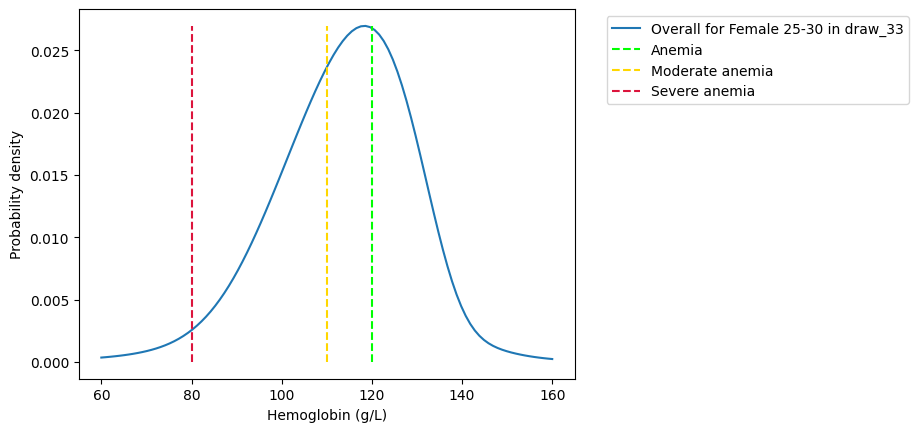

In [90]:
plot_example_distributions({"Overall": hemoglobin_distributions_by_age_sex_quintile})

In [91]:
# Assumption: non-iron-responsive anemias have same distribution of hemoglobin
# as iron-responsive anemias
non_iron_responsive_hemoglobin_distributions = truncate_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    truncate_max=hgb_info.hgb_upper_mild,
)

In [92]:
# Use even more wiggle room, as the issues in the previous check are "magnified"!
test_pdfs_cdfs_consistency(
    non_iron_responsive_hemoglobin_distributions,
    mean_tolerance=0.01,
    max_tolerance=0.10,
)

count    6.117000e+03
mean     9.365366e-04
std      3.548414e-03
min     -4.140577e-07
25%      9.083650e-06
50%      5.633019e-05
75%      3.600532e-04
max      5.400785e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.500000   1.000000    4                draw_114   -4.140577e-07
        0.076712   0.500000    4                draw_179   -2.715400e-07
                               5                draw_0     -2.564768e-07
        1.000000   2.000000    4                draw_413   -2.429491e-07
                               5                draw_108   -2.161032e-07
                                                                ...     
        0.019178   0.076712    2                draw_216    4.508913e-02
Female  95.000000  125.000000  2                draw_4      4.624367e-02
                               3                draw_483    4.945687e-02
Male    0.019178   0.076712    1                draw_65     5.272158e-02
Female  95.000000  125.000000  2                draw_416    5.400785e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.000886
std         0.003558
min        -0.000328
25%        -0.000035
50%         0.000004
75%         0.000304
max         0.054013
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000328
        0.500000   1.000000    4                draw_114   -0.000288
        1.000000   2.000000    4                draw_413   -0.000217
        0.076712   0.500000    5                draw_0     -0.000204
        1.000000   2.000000    5                draw_108   -0.000204
                                                              ...   
        0.019178   0.076712    2                draw_216    0.045094
Female  95.000000  125.000000  2                draw_4      0.046250
                               3                draw_483    0.049463
Male    0.019178   0.076712    1                draw_65     0.052726
Female  95.000000  125.000000  2                draw_416    0.054013
Length: 6117, dtype: float64

count    6117.000000
mean       -0.001460
std         0.004579
min        -0.014790
25%        -0.004318
50%        -0.001171
75%        -0.000073
max         0.052998
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   3                draw_33    -0.014790
                               5                draw_206   -0.014181
                                                draw_35    -0.014126
Female  75.000000  80.000000   5                draw_199   -0.014125
Male    10.000000  15.000000   5                draw_68    -0.013916
                                                              ...   
        0.019178   0.076712    2                draw_216    0.045100
Female  95.000000  125.000000  2                draw_4      0.045126
                               3                draw_483    0.048359
Male    0.019178   0.076712    1                draw_65     0.052731
Female  95.000000  125.000000  2                draw_416    0.052998
Length: 6117, dtype: float64

count    6117.000000
mean       -0.004903
std         0.006073
min        -0.058630
25%        -0.007578
50%        -0.004644
75%        -0.002028
max         0.052998
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_122   -0.058630
                                                draw_464   -0.053475
                                                draw_247   -0.045521
                                                draw_328   -0.041034
                                                draw_138   -0.035934
                                                              ...   
        0.019178   0.076712    2                draw_216    0.043392
Female  95.000000  125.000000  2                draw_4      0.045126
                               3                draw_483    0.048359
Male    0.019178   0.076712    1                draw_65     0.051235
Female  95.000000  125.000000  2                draw_416    0.052998
Length: 6117, dtype: float64

count    6117.000000
mean       -0.004903
std         0.006073
min        -0.058630
25%        -0.007578
50%        -0.004644
75%        -0.002028
max         0.052998
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_122   -0.058630
                                                draw_464   -0.053475
                                                draw_247   -0.045521
                                                draw_328   -0.041034
                                                draw_138   -0.035934
                                                              ...   
        0.019178   0.076712    2                draw_216    0.043392
Female  95.000000  125.000000  2                draw_4      0.045126
                               3                draw_483    0.048359
Male    0.019178   0.076712    1                draw_65     0.051235
Female  95.000000  125.000000  2                draw_416    0.052998
Length: 6117, dtype: float64

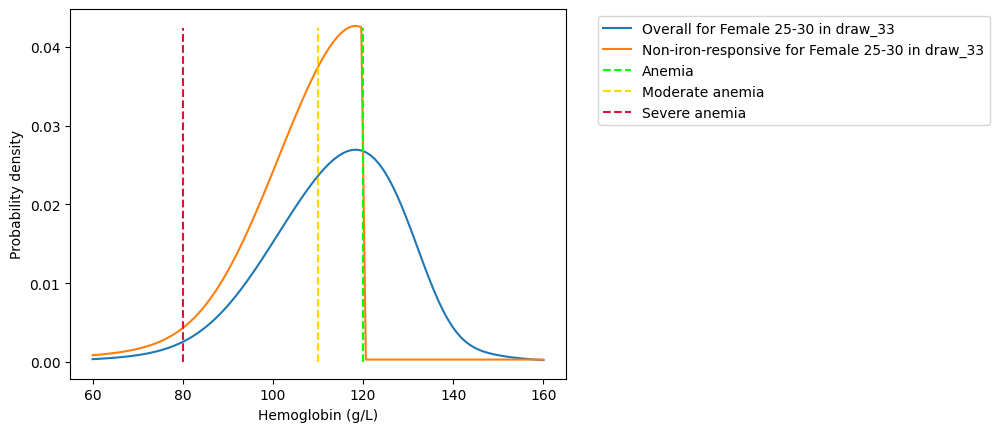

In [93]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    }
)

In [94]:
gbd_hemoglobin_distributions = distributions_from_mean_sd(
    gbd_hgb_mean, gbd_hgb_sd.loc[gbd_hgb_mean.index]
)

In [95]:
gbd_anemia_prevalence = gbd_hemoglobin_distributions.cdfs(
    thresholds.hgb_upper_mild.reindex(gbd_hgb_mean.index)
)
gbd_anemia_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.778632
                               draw_1      0.809728
                               draw_2      0.941238
                               draw_3      0.815953
                               draw_4      0.741984
                                             ...   
Male    95.0       125.000000  draw_495    0.841153
                               draw_496    0.918735
                               draw_497    0.878267
                               draw_498    0.808067
                               draw_499    0.929371
Length: 25000, dtype: float64

In [96]:
non_iron_responsive_anemia_proportion = (
    non_iron_responsive_prevalence / gbd_anemia_prevalence
)
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.145439
                               draw_1      0.126767
                               draw_2      0.139302
                               draw_3      0.101400
                               draw_4      0.176628
                                             ...   
Male    95.0       125.000000  draw_495    0.128080
                               draw_496    0.146015
                               draw_497    0.216348
                               draw_498    0.171574
                               draw_499    0.135905
Length: 25000, dtype: float64

In [97]:
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.145439
                               draw_1      0.126767
                               draw_2      0.139302
                               draw_3      0.101400
                               draw_4      0.176628
                                             ...   
Male    95.0       125.000000  draw_495    0.128080
                               draw_496    0.146015
                               draw_497    0.216348
                               draw_498    0.171574
                               draw_499    0.135905
Length: 25000, dtype: float64

In [98]:
hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.835009
                                                draw_1      0.864926
                                                draw_2      0.968674
                                                draw_3      0.890462
                                                draw_4      0.852154
                                                              ...   
Male    95.0       125.000000  5                draw_495    0.832625
                                                draw_496    0.901416
                                                draw_497    0.860296
                                                draw_498    0.797578
                                                draw_499    0.911068
Length: 125000, dtype: float64

In [99]:
non_iron_responsive_anemia_prevalence_by_age_sex_quintile = (
    (
        non_iron_responsive_anemia_proportion
        * hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)
    )
    .reorder_levels(hgb_info.index.names)
    .reindex(hgb_info.index)
)
non_iron_responsive_anemia_prevalence_by_age_sex_quintile

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.121443
                                                draw_1      0.109644
                                                draw_2      0.134939
                                                draw_3      0.090293
                                                draw_4      0.150514
                                                              ...   
Male    95.0       125.000000  5                draw_495    0.106643
                                                draw_496    0.131620
                                                draw_497    0.186123
                                                draw_498    0.136844
                                                draw_499    0.123819
Length: 125000, dtype: float64

In [100]:
iron_responsive_distributions = delete_from_mixture_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    non_iron_responsive_hemoglobin_distributions,
    non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
)

In [101]:
test_pdfs_cdfs_consistency(
    iron_responsive_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6117.000000
mean        0.000536
std         0.002368
min        -0.000009
25%         0.000003
50%         0.000023
75%         0.000146
max         0.038122
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    30.000000  35.000000   2                draw_118   -0.000009
        5.000000   10.000000   3                draw_456   -0.000008
        10.000000  15.000000   1                draw_477   -0.000005
        40.000000  45.000000   5                draw_444   -0.000002
        25.000000  30.000000   3                draw_199   -0.000002
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030386
        95.000000  125.000000  4                draw_10     0.030440
Female  95.000000  125.000000  3                draw_483    0.031123
                               2                draw_416    0.035857
Male    0.019178   0.076712    1                draw_65     0.038122
Length: 6117, dtype: float64

count    6.117000e+03
mean     5.103028e-04
std      2.373160e-03
min     -3.219180e-04
25%     -1.543769e-05
50%      9.459414e-07
75%      1.135842e-04
max      3.812465e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000322
        0.500000   1.000000    4                draw_114   -0.000280
        1.000000   2.000000    4                draw_413   -0.000198
                               5                draw_108   -0.000170
        0.076712   0.500000    5                draw_0     -0.000169
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030390
        95.000000  125.000000  4                draw_10     0.030444
Female  95.000000  125.000000  3                draw_483    0.031126
                               2                draw_416    0.035860
Male    0.019178   0.076712    1                draw_65     0.038125
Length: 6117, dtype: float64

count    6117.000000
mean        0.000903
std         0.002353
min        -0.000398
25%         0.000017
50%         0.000568
75%         0.000859
max         0.038129
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161   -0.000398
        35.000000  40.000000   1                draw_119   -0.000340
        30.000000  35.000000   5                draw_397   -0.000326
        35.000000  40.000000   3                draw_119   -0.000315
        30.000000  35.000000   5                draw_395   -0.000312
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030394
        95.000000  125.000000  4                draw_10     0.030452
Female  95.000000  125.000000  3                draw_483    0.031279
                               2                draw_416    0.036003
Male    0.019178   0.076712    1                draw_65     0.038129
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.184724e-03
std      2.317039e-03
min      4.794021e-07
25%      5.464053e-04
50%      7.480544e-04
75%      1.014779e-03
max      3.823241e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161    4.794021e-07
                                                draw_84     5.614089e-06
                                                draw_104    7.807533e-06
        90.000000  95.000000   1                draw_340    8.561777e-06
        0.000000   0.019178    1                draw_410    9.526194e-06
                                                                ...     
        0.019178   0.076712    2                draw_216    3.054863e-02
        95.000000  125.000000  4                draw_10     3.064650e-02
Female  95.000000  125.000000  3                draw_483    3.128652e-02
                               2                draw_416    3.600815e-02
Male    0.019178   0.076712    1                draw_65     3.823241e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.160051e-03
std      2.316651e-03
min      3.593876e-07
25%      5.266937e-04
50%      7.268782e-04
75%      9.781090e-04
max      3.822726e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161    3.593876e-07
                                                draw_84     3.913241e-06
                                                draw_104    6.057432e-06
                                                draw_410    7.057604e-06
        90.000000  95.000000   1                draw_340    8.561777e-06
                                                                ...     
        0.019178   0.076712    2                draw_216    3.054449e-02
        95.000000  125.000000  4                draw_10     3.063584e-02
Female  95.000000  125.000000  3                draw_483    3.127697e-02
                               2                draw_416    3.599885e-02
Male    0.019178   0.076712    1                draw_65     3.822726e-02
Length: 6117, dtype: float64

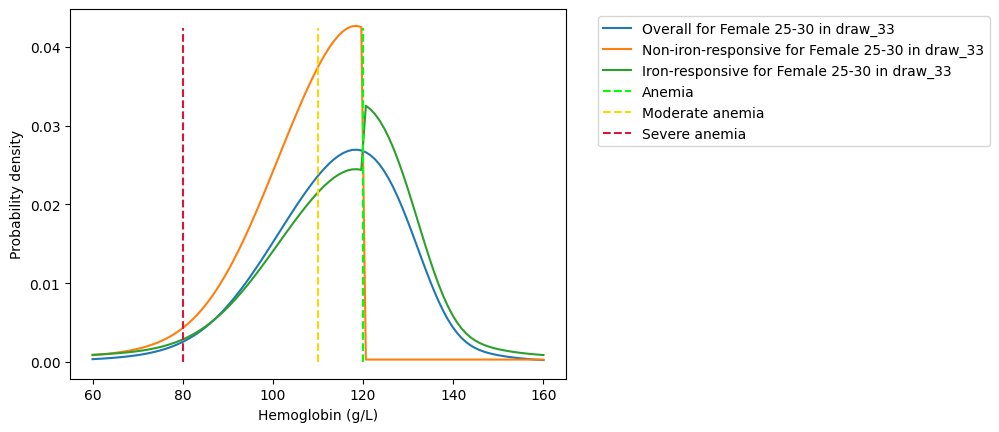

In [102]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive": iron_responsive_distributions,
    }
)

In [103]:
# NOTE: this decomposition, like what we do for wealth quintile above,
# is not exact -- we pretend that these two distributions would mix
# to the overall iron-responsive distribution, but they wouldn't.
# Here, we delete baseline coverage to get the without-fortification distribution.
# Also note that this and the next shift both assume that the hemoglobin effect among
# the responsive is a fixed value without individual-level variation.
iron_responsive_without_fortification_distributions = shift_distributions(
    iron_responsive_distributions,
    -effective_coverage_2021 * hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [104]:
test_pdfs_cdfs_consistency(
    iron_responsive_without_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6117.000000
mean        0.000536
std         0.002368
min        -0.000009
25%         0.000003
50%         0.000023
75%         0.000146
max         0.038122
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    30.000000  35.000000   2                draw_118   -0.000009
        5.000000   10.000000   3                draw_456   -0.000008
        10.000000  15.000000   1                draw_477   -0.000005
        40.000000  45.000000   5                draw_444   -0.000002
        25.000000  30.000000   3                draw_199   -0.000002
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030386
        95.000000  125.000000  4                draw_10     0.030440
Female  95.000000  125.000000  3                draw_483    0.031123
                               2                draw_416    0.035857
Male    0.019178   0.076712    1                draw_65     0.038122
Length: 6117, dtype: float64

count    6.117000e+03
mean     5.103028e-04
std      2.373160e-03
min     -3.219180e-04
25%     -1.543769e-05
50%      9.459414e-07
75%      1.135842e-04
max      3.812465e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000322
        0.500000   1.000000    4                draw_114   -0.000280
        1.000000   2.000000    4                draw_413   -0.000198
                               5                draw_108   -0.000170
        0.076712   0.500000    5                draw_0     -0.000169
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030390
        95.000000  125.000000  4                draw_10     0.030444
Female  95.000000  125.000000  3                draw_483    0.031126
                               2                draw_416    0.035860
Male    0.019178   0.076712    1                draw_65     0.038125
Length: 6117, dtype: float64

count    6117.000000
mean        0.000903
std         0.002353
min        -0.000398
25%         0.000017
50%         0.000568
75%         0.000859
max         0.038129
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161   -0.000398
        35.000000  40.000000   1                draw_119   -0.000340
        30.000000  35.000000   5                draw_397   -0.000326
        35.000000  40.000000   3                draw_119   -0.000315
        30.000000  35.000000   5                draw_395   -0.000312
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030394
        95.000000  125.000000  4                draw_10     0.030452
Female  95.000000  125.000000  3                draw_483    0.031279
                               2                draw_416    0.036003
Male    0.019178   0.076712    1                draw_65     0.038129
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.184724e-03
std      2.317039e-03
min      4.794021e-07
25%      5.464053e-04
50%      7.480544e-04
75%      1.014779e-03
max      3.823241e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161    4.794021e-07
                                                draw_84     5.614089e-06
                                                draw_104    7.807533e-06
        90.000000  95.000000   1                draw_340    8.561777e-06
        0.000000   0.019178    1                draw_410    9.526194e-06
                                                                ...     
        0.019178   0.076712    2                draw_216    3.054863e-02
        95.000000  125.000000  4                draw_10     3.064650e-02
Female  95.000000  125.000000  3                draw_483    3.128652e-02
                               2                draw_416    3.600815e-02
Male    0.019178   0.076712    1                draw_65     3.823241e-02
Length: 6117, dtype: float64

count    6.117000e+03
mean     1.160051e-03
std      2.316651e-03
min      3.593876e-07
25%      5.266937e-04
50%      7.268782e-04
75%      9.781090e-04
max      3.822726e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161    3.593876e-07
                                                draw_84     3.913241e-06
                                                draw_104    6.057432e-06
                                                draw_410    7.057604e-06
        90.000000  95.000000   1                draw_340    8.561777e-06
                                                                ...     
        0.019178   0.076712    2                draw_216    3.054449e-02
        95.000000  125.000000  4                draw_10     3.063584e-02
Female  95.000000  125.000000  3                draw_483    3.127697e-02
                               2                draw_416    3.599885e-02
Male    0.019178   0.076712    1                draw_65     3.822726e-02
Length: 6117, dtype: float64

In [105]:
iron_responsive_with_fortification_distributions = shift_distributions(
    iron_responsive_without_fortification_distributions,
    hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [106]:
test_pdfs_cdfs_consistency(
    iron_responsive_with_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6117.000000
mean        0.000539
std         0.002377
min        -0.000009
25%         0.000003
50%         0.000023
75%         0.000148
max         0.038233
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    30.000000  35.000000   2                draw_118   -0.000009
        5.000000   10.000000   3                draw_456   -0.000008
        10.000000  15.000000   1                draw_477   -0.000005
        40.000000  45.000000   5                draw_444   -0.000002
        25.000000  30.000000   3                draw_199   -0.000002
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030481
        95.000000  125.000000  4                draw_10     0.030542
Female  95.000000  125.000000  3                draw_483    0.031226
                               2                draw_416    0.035968
Male    0.019178   0.076712    1                draw_65     0.038233
Length: 6117, dtype: float64

count    6117.000000
mean        0.000517
std         0.002381
min        -0.000234
25%        -0.000008
50%         0.000003
75%         0.000117
max         0.038236
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000234
        0.500000   1.000000    4                draw_114   -0.000223
        1.000000   2.000000    4                draw_413   -0.000163
                               5                draw_108   -0.000122
        0.076712   0.500000    4                draw_148   -0.000120
                                                              ...   
        0.019178   0.076712    2                draw_216    0.030485
        95.000000  125.000000  4                draw_10     0.030547
Female  95.000000  125.000000  3                draw_483    0.031230
                               2                draw_416    0.035971
Male    0.019178   0.076712    1                draw_65     0.038236
Length: 6117, dtype: float64

count    6117.000000
mean       -0.000569
std         0.002818
min        -0.015636
25%        -0.001789
50%        -0.000809
75%        -0.000017
max         0.038240
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   1                draw_184   -0.015636
        5.000000   10.000000   1                draw_307   -0.013050
        10.000000  15.000000   2                draw_96    -0.012017
                               1                draw_429   -0.011647
Female  10.000000  15.000000   1                draw_67    -0.011354
                                                              ...   
Male    0.019178   0.076712    2                draw_216    0.030488
        95.000000  125.000000  4                draw_10     0.030554
Female  95.000000  125.000000  3                draw_483    0.030865
                               2                draw_416    0.035625
Male    0.019178   0.076712    1                draw_65     0.038240
Length: 6117, dtype: float64

count    6117.000000
mean       -0.000936
std         0.002803
min        -0.016752
25%        -0.001916
50%        -0.001300
75%        -0.000621
max         0.038146
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   1                draw_184   -0.016752
        5.000000   10.000000   1                draw_307   -0.013748
        10.000000  15.000000   2                draw_96    -0.013532
Female  10.000000  15.000000   1                draw_67    -0.012138
Male    10.000000  15.000000   1                draw_429   -0.011990
                                                              ...   
        95.000000  125.000000  4                draw_10     0.030301
        0.019178   0.076712    2                draw_216    0.030346
Female  95.000000  125.000000  3                draw_483    0.030873
                               2                draw_416    0.035632
Male    0.019178   0.076712    1                draw_65     0.038146
Length: 6117, dtype: float64

count    6117.000000
mean       -0.000968
std         0.002799
min        -0.016752
25%        -0.001928
50%        -0.001333
75%        -0.000657
max         0.038142
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   1                draw_184   -0.016752
        5.000000   10.000000   1                draw_307   -0.013748
        10.000000  15.000000   2                draw_96    -0.013532
Female  10.000000  15.000000   1                draw_67    -0.012138
Male    10.000000  15.000000   1                draw_429   -0.011990
                                                              ...   
        95.000000  125.000000  4                draw_10     0.030291
        0.019178   0.076712    2                draw_216    0.030344
Female  95.000000  125.000000  3                draw_483    0.030864
                               2                draw_416    0.035622
Male    0.019178   0.076712    1                draw_65     0.038142
Length: 6117, dtype: float64

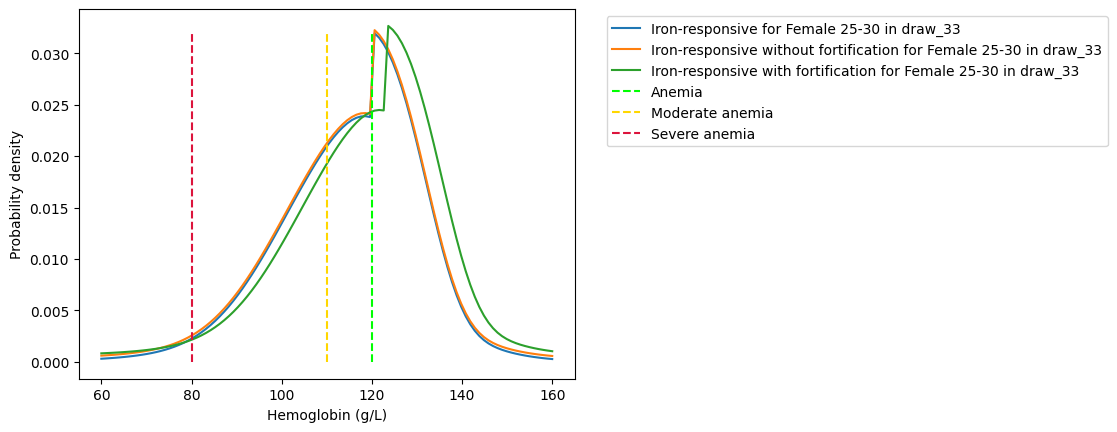

In [107]:
plot_example_distributions(
    {
        "Iron-responsive": iron_responsive_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

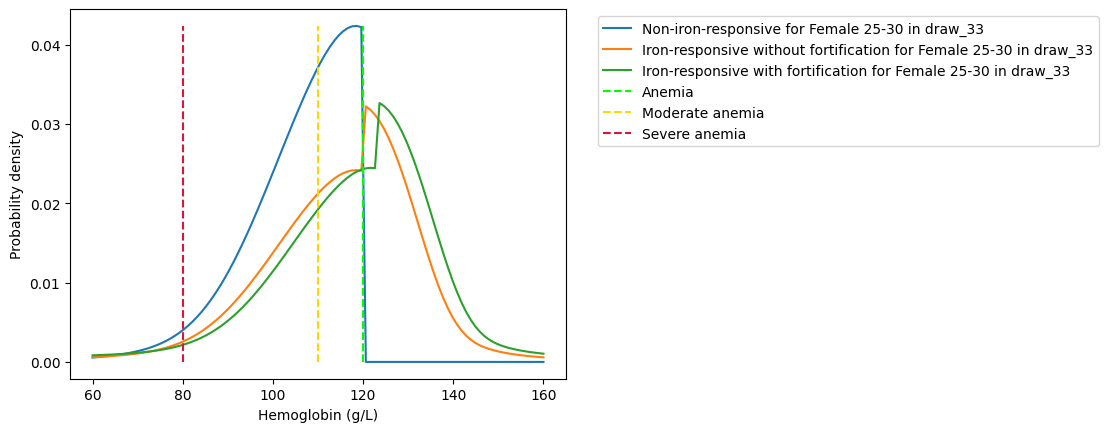

In [108]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

In [109]:
zero_fort_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
    ]
)

In [110]:
test_pdfs_cdfs_consistency(
    zero_fort_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     5.757677e-04
std      2.480615e-03
min     -4.047475e-07
25%      3.913192e-06
50%      2.660410e-05
75%      1.712735e-04
max      3.901132e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.500000   1.000000    4                draw_114   -4.047475e-07
        0.076712   0.500000    4                draw_179   -2.673723e-07
        1.000000   2.000000    4                draw_413   -2.248306e-07
        0.076712   0.500000    5                draw_0     -2.183600e-07
        1.000000   2.000000    5                draw_108   -1.848384e-07
                                                                ...     
        0.019178   0.076712    2                draw_216    3.154972e-02
        95.000000  125.000000  4                draw_10     3.175158e-02
Female  95.000000  125.000000  3                draw_483    3.325883e-02
                               2                draw_416    3.798612e-02
Male    0.019178   0.076712    1                draw_65     3.901132e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.000547
std         0.002486
min        -0.000323
25%        -0.000018
50%         0.000001
75%         0.000139
max         0.039014
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000323
        0.500000   1.000000    4                draw_114   -0.000281
        1.000000   2.000000    4                draw_413   -0.000201
                               5                draw_108   -0.000175
        0.076712   0.500000    5                draw_0     -0.000174
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031553
        95.000000  125.000000  4                draw_10     0.031756
Female  95.000000  125.000000  3                draw_483    0.033263
                               2                draw_416    0.037990
Male    0.019178   0.076712    1                draw_65     0.039014
Length: 6117, dtype: float64

count    6117.000000
mean        0.000604
std         0.002480
min        -0.000398
25%        -0.000001
50%         0.000113
75%         0.000254
max         0.039019
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161   -0.000398
        35.000000  40.000000   1                draw_119   -0.000371
        30.000000  35.000000   5                draw_397   -0.000371
                                                draw_395   -0.000355
        35.000000  40.000000   3                draw_119   -0.000354
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031557
        95.000000  125.000000  4                draw_10     0.031764
Female  95.000000  125.000000  3                draw_483    0.033269
                               2                draw_416    0.037997
Male    0.019178   0.076712    1                draw_65     0.039019
Length: 6117, dtype: float64

count    6117.000000
mean        0.000601
std         0.002481
min        -0.000294
25%         0.000015
50%         0.000071
75%         0.000199
max         0.039025
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_122   -0.000294
                                                draw_464   -0.000247
                                                draw_247   -0.000227
                                                draw_328   -0.000193
                                                draw_405   -0.000113
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031565
        95.000000  125.000000  4                draw_10     0.031769
Female  95.000000  125.000000  3                draw_483    0.033276
                               2                draw_416    0.038001
Male    0.019178   0.076712    1                draw_65     0.039025
Length: 6117, dtype: float64

count    6.117000e+03
mean     5.786523e-04
std      2.482430e-03
min     -1.406653e-13
25%      4.588283e-06
50%      2.798501e-05
75%      1.750374e-04
max      3.901995e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_104   -1.406653e-13
                                                draw_138    2.031708e-14
                               3                draw_115    3.730349e-14
        10.000000  15.000000   2                draw_96     7.283063e-14
        40.000000  45.000000   5                draw_17     7.616130e-14
                                                                ...     
        0.019178   0.076712    2                draw_216    3.156103e-02
        95.000000  125.000000  4                draw_10     3.175996e-02
Female  95.000000  125.000000  3                draw_483    3.326733e-02
                               2                draw_416    3.799303e-02
Male    0.019178   0.076712    1                draw_65     3.901995e-02
Length: 6117, dtype: float64

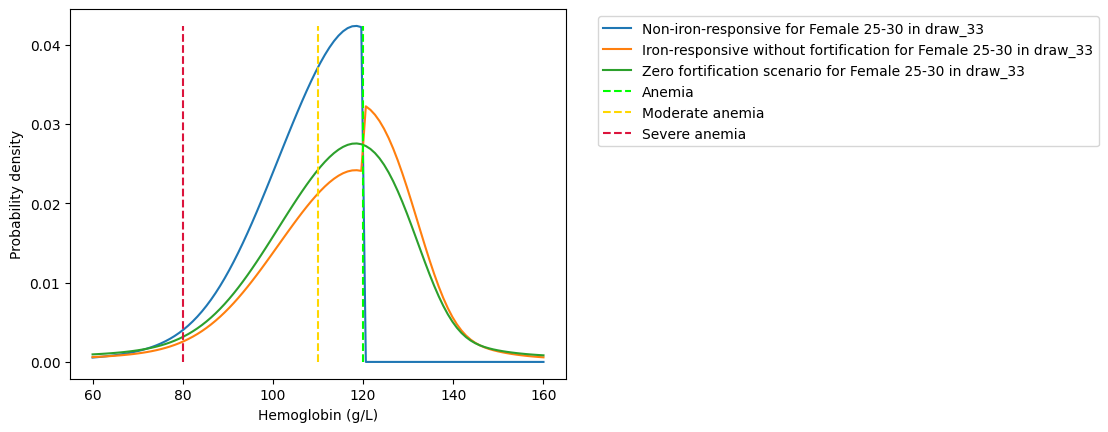

In [111]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Zero fortification scenario": zero_fort_scenario_distributions,
    }
)

In [112]:
baseline_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * (1 - effective_coverage_baseline),
        ),
        (
            iron_responsive_with_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * effective_coverage_baseline,
        ),
    ]
)

In [113]:
test_pdfs_cdfs_consistency(
    baseline_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    6.117000e+03
mean     5.757677e-04
std      2.480615e-03
min     -4.047475e-07
25%      3.913192e-06
50%      2.660410e-05
75%      1.712735e-04
max      3.901132e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.500000   1.000000    4                draw_114   -4.047475e-07
        0.076712   0.500000    4                draw_179   -2.673723e-07
        1.000000   2.000000    4                draw_413   -2.248306e-07
        0.076712   0.500000    5                draw_0     -2.183600e-07
        1.000000   2.000000    5                draw_108   -1.848384e-07
                                                                ...     
        0.019178   0.076712    2                draw_216    3.154972e-02
        95.000000  125.000000  4                draw_10     3.175158e-02
Female  95.000000  125.000000  3                draw_483    3.325883e-02
                               2                draw_416    3.798612e-02
Male    0.019178   0.076712    1                draw_65     3.901132e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.000547
std         0.002486
min        -0.000323
25%        -0.000018
50%         0.000001
75%         0.000139
max         0.039014
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000323
        0.500000   1.000000    4                draw_114   -0.000281
        1.000000   2.000000    4                draw_413   -0.000201
                               5                draw_108   -0.000175
        0.076712   0.500000    5                draw_0     -0.000174
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031553
        95.000000  125.000000  4                draw_10     0.031756
Female  95.000000  125.000000  3                draw_483    0.033263
                               2                draw_416    0.037990
Male    0.019178   0.076712    1                draw_65     0.039014
Length: 6117, dtype: float64

count    6117.000000
mean        0.000604
std         0.002480
min        -0.000398
25%        -0.000001
50%         0.000113
75%         0.000254
max         0.039019
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    1                draw_161   -0.000398
        35.000000  40.000000   1                draw_119   -0.000371
        30.000000  35.000000   5                draw_397   -0.000371
                                                draw_395   -0.000355
        35.000000  40.000000   3                draw_119   -0.000354
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031557
        95.000000  125.000000  4                draw_10     0.031764
Female  95.000000  125.000000  3                draw_483    0.033269
                               2                draw_416    0.037997
Male    0.019178   0.076712    1                draw_65     0.039019
Length: 6117, dtype: float64

count    6117.000000
mean        0.000601
std         0.002481
min        -0.000294
25%         0.000015
50%         0.000071
75%         0.000199
max         0.039025
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_122   -0.000294
                                                draw_464   -0.000247
                                                draw_247   -0.000227
                                                draw_328   -0.000193
                                                draw_405   -0.000113
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031565
        95.000000  125.000000  4                draw_10     0.031769
Female  95.000000  125.000000  3                draw_483    0.033276
                               2                draw_416    0.038001
Male    0.019178   0.076712    1                draw_65     0.039025
Length: 6117, dtype: float64

count    6.117000e+03
mean     5.786523e-04
std      2.482430e-03
min     -1.406653e-13
25%      4.588283e-06
50%      2.798501e-05
75%      1.750374e-04
max      3.901995e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.000000   0.019178    5                draw_104   -1.406653e-13
                                                draw_138    2.031708e-14
                               3                draw_115    3.730349e-14
        10.000000  15.000000   2                draw_96     7.283063e-14
        40.000000  45.000000   5                draw_17     7.616130e-14
                                                                ...     
        0.019178   0.076712    2                draw_216    3.156103e-02
        95.000000  125.000000  4                draw_10     3.175996e-02
Female  95.000000  125.000000  3                draw_483    3.326733e-02
                               2                draw_416    3.799303e-02
Male    0.019178   0.076712    1                draw_65     3.901995e-02
Length: 6117, dtype: float64

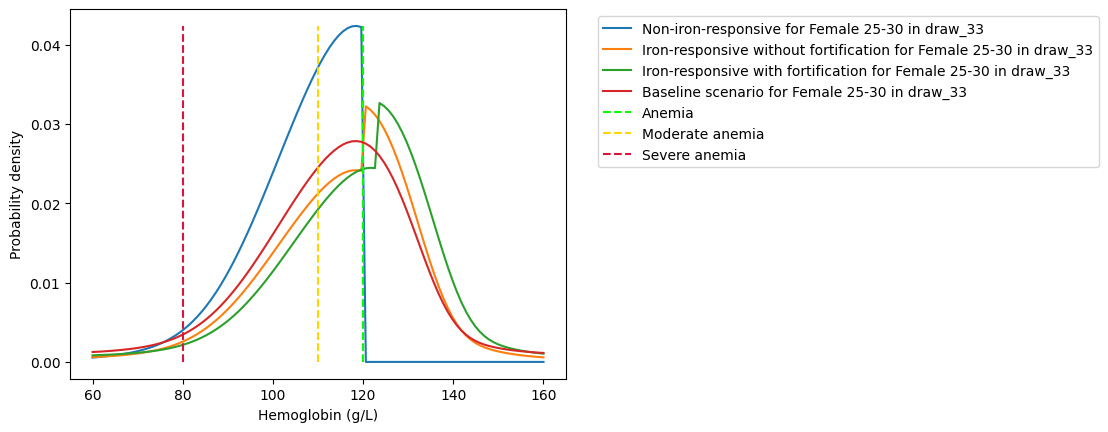

In [114]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
        "Baseline scenario": baseline_scenario_distributions,
    }
)

In [115]:
intervention_scenario_distributions = {}

for intervention_scenario in intervention_scenarios:
    effective_coverage_for_scenario = (
        effective_coverage_intervention[
            effective_coverage_intervention.index.get_level_values("scenario")
            == intervention_scenario
        ]
        .droplevel("scenario")
        .reindex(hgb_info.index)
    )
    intervention_scenario_distributions[intervention_scenario] = mix_distributions(
        [
            (
                non_iron_responsive_hemoglobin_distributions,
                non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
            ),
            (
                iron_responsive_without_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * (1 - effective_coverage_for_scenario),
            ),
            (
                iron_responsive_with_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * effective_coverage_for_scenario,
            ),
        ]
    )

In [116]:
for _, dists in intervention_scenario_distributions.items():
    test_pdfs_cdfs_consistency(
        dists,
        mean_tolerance=0.005,
        max_tolerance=0.05,
    )

count    6.117000e+03
mean     5.760941e-04
std      2.481574e-03
min     -3.783180e-07
25%      3.929066e-06
50%      2.663875e-05
75%      1.714069e-04
max      3.901984e-02
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.500000   1.000000    4                draw_114   -3.783180e-07
        0.076712   0.500000    4                draw_179   -2.506501e-07
                               5                draw_0     -1.956897e-07
        1.000000   2.000000    4                draw_413   -1.842843e-07
                               5                draw_108   -1.566034e-07
                                                                ...     
        0.019178   0.076712    2                draw_216    3.155920e-02
        95.000000  125.000000  4                draw_10     3.176540e-02
Female  95.000000  125.000000  3                draw_483    3.327093e-02
                               2                draw_416    3.799678e-02
Male    0.019178   0.076712    1                draw_65     3.901984e-02
Length: 6117, dtype: float64

count    6117.000000
mean        0.000548
std         0.002487
min        -0.000311
25%        -0.000017
50%         0.000002
75%         0.000139
max         0.039023
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    0.076712   0.500000    4                draw_179   -0.000311
        0.500000   1.000000    4                draw_114   -0.000274
        1.000000   2.000000    4                draw_413   -0.000196
                               5                draw_108   -0.000168
        0.076712   0.500000    5                draw_0     -0.000166
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031563
        95.000000  125.000000  4                draw_10     0.031770
Female  95.000000  125.000000  3                draw_483    0.033275
                               2                draw_416    0.038001
Male    0.019178   0.076712    1                draw_65     0.039023
Length: 6117, dtype: float64

count    6117.000000
mean        0.000440
std         0.002510
min        -0.001205
25%        -0.000170
50%        -0.000055
75%         0.000114
max         0.039027
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   3                draw_77    -0.001205
                               2                draw_96    -0.001030
        5.000000   10.000000   4                draw_307   -0.000978
Female  5.000000   10.000000   5                draw_311   -0.000939
Male    5.000000   10.000000   3                draw_458   -0.000935
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031567
        95.000000  125.000000  4                draw_10     0.031778
Female  95.000000  125.000000  3                draw_483    0.033221
                               2                draw_416    0.037960
Male    0.019178   0.076712    1                draw_65     0.039027
Length: 6117, dtype: float64

count    6117.000000
mean        0.000362
std         0.002522
min        -0.001465
25%        -0.000274
50%        -0.000138
75%         0.000048
max         0.039018
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   2                draw_96    -0.001465
Female  5.000000   10.000000   4                draw_495   -0.001322
Male    5.000000   10.000000   4                draw_307   -0.001297
Female  5.000000   10.000000   5                draw_11    -0.001268
Male    10.000000  15.000000   1                draw_184   -0.001177
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031545
        95.000000  125.000000  4                draw_10     0.031723
Female  95.000000  125.000000  3                draw_483    0.033227
                               2                draw_416    0.037965
Male    0.019178   0.076712    1                draw_65     0.039018
Length: 6117, dtype: float64

count    6117.000000
mean        0.000339
std         0.002524
min        -0.001465
25%        -0.000292
50%        -0.000170
75%         0.000005
max         0.039013
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    10.000000  15.000000   2                draw_96    -0.001465
Female  5.000000   10.000000   4                draw_495   -0.001322
Male    5.000000   10.000000   4                draw_307   -0.001297
Female  5.000000   10.000000   5                draw_11    -0.001268
Male    10.000000  15.000000   1                draw_184   -0.001177
                                                              ...   
        0.019178   0.076712    2                draw_216    0.031541
        95.000000  125.000000  4                draw_10     0.031713
Female  95.000000  125.000000  3                draw_483    0.033219
                               2                draw_416    0.037957
Male    0.019178   0.076712    1                draw_65     0.039013
Length: 6117, dtype: float64

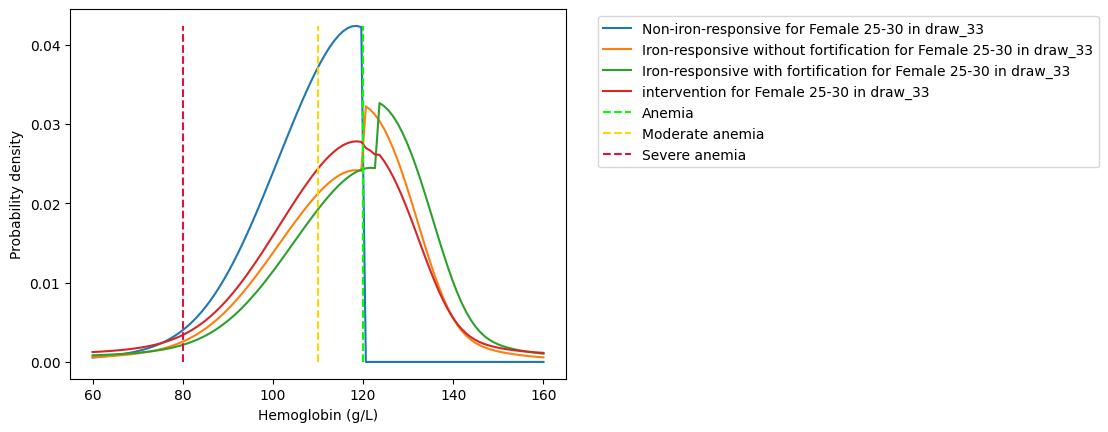

In [117]:
for intervention_scenario in intervention_scenarios:
    plot_example_distributions(
        {
            "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
            "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
            "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
            intervention_scenario: intervention_scenario_distributions[
                intervention_scenario
            ],
        }
    )
    plt.show()

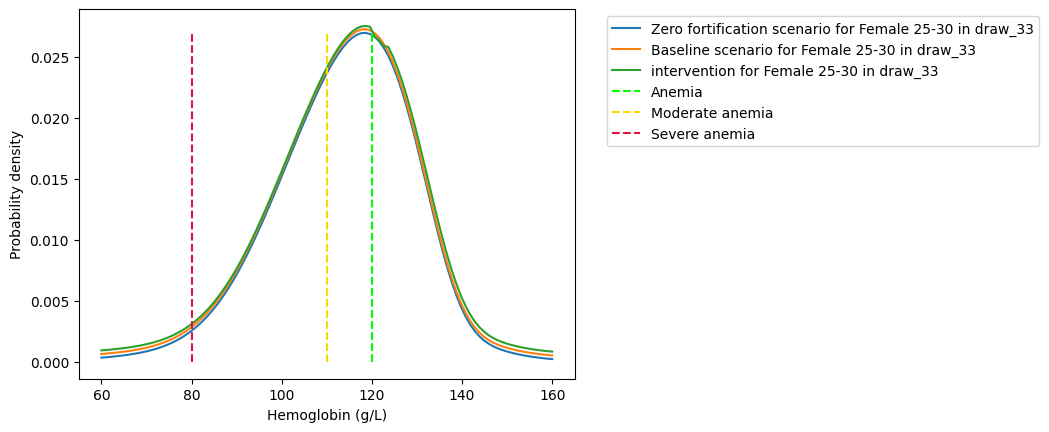

In [118]:
plot_example_distributions(
    {
        "Zero fortification scenario": zero_fort_scenario_distributions,
        "Baseline scenario": baseline_scenario_distributions,
        **intervention_scenario_distributions,
    }
)

In [119]:
def anemia_by_severity_from_distributions(distributions: Distributions):
    result = pd.DataFrame(index=distributions.data_index)
    assert result.index.equals(hgb_info.index)

    result["severe"] = distributions.cdfs(
        hgb_info.hgb_upper_severe.copy()
    ) - distributions.cdfs(hgb_info.hgb_lower_severe.copy())
    result["moderate"] = (
        distributions.cdfs(hgb_info.hgb_upper_moderate.copy()) - result["severe"]
    )
    result["mild"] = (
        distributions.cdfs(hgb_info.hgb_upper_mild.copy())
        - result["moderate"]
        - result["severe"]
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    assert (result >= 0).all().all()
    assert (result <= 1).all().all()
    return result

In [120]:
zero_fort_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    zero_fort_scenario_distributions
)
zero_fort_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_2    0.048532  0.734690   
                                            draw_3    0.042398  0.586287   
                                            draw_4    0.021629  0.516715   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.259055  0.349079   
                                            draw_496  0.063503  0.435526   
                                            draw_497  0.101301  0.410033   
                                            draw_498  0.245769  0.329388   
                                            draw_499  0.044169  0.427180   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_2    0.185452  0.968674  
                                            draw_3    0.261777  0.890462  
                                            draw_4    0.313810  0.852154  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.224492  0.832625  
                                            draw_496  0.402387  0.901416  
                                            draw_497  0.348962  0.860296  
                                            draw_498  0.222421  0.797578  
                                            draw_499  0.439720  0.911068  

[125000 rows x 4 columns]

In [121]:
baseline_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    baseline_scenario_distributions
)
baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_2    0.048532  0.734690   
                                            draw_3    0.042398  0.586287   
                                            draw_4    0.021629  0.516715   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.259055  0.349079   
                                            draw_496  0.063503  0.435526   
                                            draw_497  0.101301  0.410033   
                                            draw_498  0.245769  0.329388   
                                            draw_499  0.044169  0.427180   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_2    0.185452  0.968674  
                                            draw_3    0.261777  0.890462  
                                            draw_4    0.313810  0.852154  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.224492  0.832625  
                                            draw_496  0.402387  0.901416  
                                            draw_497  0.348962  0.860296  
                                            draw_498  0.222421  0.797578  
                                            draw_499  0.439720  0.911068  

[125000 rows x 4 columns]

In [122]:
intervention_scenarios_anemia_by_severity = {}

for scenario, distributions in intervention_scenario_distributions.items():
    anemia_by_severity = anemia_by_severity_from_distributions(distributions)
    print(scenario)
    display(anemia_by_severity)
    intervention_scenarios_anemia_by_severity[scenario] = anemia_by_severity

intervention


severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.111572  0.520053   
                                            draw_1    0.097974  0.554978   
                                            draw_2    0.047634  0.730492   
                                            draw_3    0.041668  0.581895   
                                            draw_4    0.021279  0.512015   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.255695  0.346478   
                                            draw_496  0.061194  0.427432   
                                            draw_497  0.098537  0.404778   
                                            draw_498  0.242959  0.326814   
                                            draw_499  0.042412  0.417627   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.200619  0.832244  
                                            draw_1    0.209172  0.862124  
                                            draw_2    0.189120  0.967246  
                                            draw_3    0.263522  0.887084  
                                            draw_4    0.314826  0.848120  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.225743  0.827917  
                                            draw_496  0.405970  0.894595  
                                            draw_497  0.350815  0.854130  
                                            draw_498  0.223178  0.792951  
                                            draw_499  0.443778  0.903816  

[125000 rows x 4 columns]

In [123]:
# Transform the intervention scenarios back from a dictionary to the scenario being a level
# in the MultiIndex, which is easier to work with now that we are out of function/distribution space.
intervention_scenarios_anemia_by_severity = pd.concat(
    [
        anemia_by_severity.assign(scenario=scenario).set_index("scenario", append=True)
        for scenario, anemia_by_severity in intervention_scenarios_anemia_by_severity.items()
    ]
)
intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.111572   
                                            draw_1   intervention  0.097974   
                                            draw_2   intervention  0.047634   
                                            draw_3   intervention  0.041668   
                                            draw_4   intervention  0.021279   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.255695   
                                            draw_496 intervention  0.061194   
                                            draw_497 intervention  0.098537   
                                            draw_498 intervention  0.242959   
                                            draw_499 intervention  0.042412   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.520053   
                                            draw_1   intervention  0.554978   
                                            draw_2   intervention  0.730492   
                                            draw_3   intervention  0.581895   
                                            draw_4   intervention  0.512015   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.346478   
                                            draw_496 intervention  0.427432   
                                            draw_497 intervention  0.404778   
                                            draw_498 intervention  0.326814   
                                            draw_499 intervention  0.417627   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.200619   
                                            draw_1   intervention  0.209172   
                                            draw_2   intervention  0.189120   
                                            draw_3   intervention  0.263522   
                                            draw_4   intervention  0.314826   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.225743   
                                            draw_496 intervention  0.405970   
                                            draw_497 intervention  0.350815   
                                            draw_498 intervention  0.223178   
                                            draw_499 intervention  0.443778   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.832244  
                                            draw_1   intervention  0.862124  
                                            draw_2   intervention  0.967246  
                                            draw_3   intervention  0.887084  
                                            draw_4   intervention  0.848120  
...                                                                     ...  
Male   95.0      125.000000 5               draw_495 intervention  0.827917  
                                            draw_496 intervention  0.894595  
                                            draw_497 intervention  0.854130  
                                            draw_498 intervention  0.792951  
                                            draw_

In [124]:
zero_fort_scenario_anemia_by_severity - baseline_scenario_anemia_by_severity

severe  moderate  mild  \
sex    age_start age_end    wealth_quintile draw                               
Female 0.0       0.019178   1               draw_0       0.0       0.0   0.0   
                                            draw_1       0.0       0.0   0.0   
                                            draw_2       0.0       0.0   0.0   
                                            draw_3       0.0       0.0   0.0   
                                            draw_4       0.0       0.0   0.0   
...                                                      ...       ...   ...   
Male   95.0      125.000000 5               draw_495     0.0       0.0   0.0   
                                            draw_496     0.0       0.0   0.0   
                                            draw_497     0.0       0.0   0.0   
                                            draw_498     0.0       0.0   0.0   
                                            draw_499     0.0       0.0   0.0   

                                                      anemic  
sex    age_start age_end    wealth_quintile draw              
Female 0.0       0.019178   1               draw_0       0.0  
                                            draw_1       0.0  
                                            draw_2       0.0  
                                            draw_3       0.0  
                                            draw_4       0.0  
...                                                      ...  
Male   95.0      125.000000 5               draw_495     0.0  
                                            draw_496     0.0  
                                            draw_497     0.0  
                                            draw_498     0.0  
                                            draw_499     0.0  

[125000 rows x 4 columns]

In [125]:
baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.001290   
                                            draw_1   intervention  0.001287   
                                            draw_2   intervention  0.000899   
                                            draw_3   intervention  0.000731   
                                            draw_4   intervention  0.000350   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.003359   
                                            draw_496 intervention  0.002309   
                                            draw_497 intervention  0.002764   
                                            draw_498 intervention  0.002811   
                                            draw_499 intervention  0.001757   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.002185   
                                            draw_1   intervention  0.002570   
                                            draw_2   intervention  0.004198   
                                            draw_3   intervention  0.004392   
                                            draw_4   intervention  0.004700   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention  0.002600   
                                            draw_496 intervention  0.008095   
                                            draw_497 intervention  0.005256   
                                            draw_498 intervention  0.002574   
                                            draw_499 intervention  0.009553   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention -0.000710   
                                            draw_1   intervention -0.001055   
                                            draw_2   intervention -0.003668   
                                            draw_3   intervention -0.001745   
                                            draw_4   intervention -0.001016   
...                                                                     ...   
Male   95.0      125.000000 5               draw_495 intervention -0.001252   
                                            draw_496 intervention -0.003583   
                                            draw_497 intervention -0.001853   
                                            draw_498 intervention -0.000757   
                                            draw_499 intervention -0.004058   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.002765  
                                            draw_1   intervention  0.002802  
                                            draw_2   intervention  0.001428  
                                            draw_3   intervention  0.003377  
                                            draw_4   intervention  0.004034  
...                                                                     ...  
Male   95.0      125.000000 5               draw_495 intervention  0.004708  
                                            draw_496 intervention  0.006821  
                                            draw_497 intervention  0.006166  
                                            draw_498 intervention  0.004627  
                                            draw_

<Axes: >

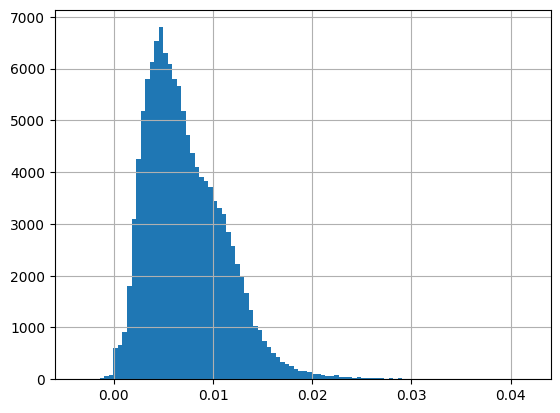

In [126]:
# We can see that in very rare cases, likely due to numerical instability, we get a negative impact
(
    baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity
).anemic.hist(bins=100)

In [127]:
def anemia_by_severity_to_yld_rates(anemia_by_severity):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia_by_severity.index
    anemia_by_severity = (
        anemia_by_severity.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia_by_severity["mild_yld_rate"] = (
        anemia_by_severity.mild * anemia_by_severity.mild_dw
    )
    anemia_by_severity["moderate_yld_rate"] = (
        anemia_by_severity.moderate * anemia_by_severity.moderate_dw
    )
    anemia_by_severity["severe_yld_rate"] = (
        anemia_by_severity.severe * anemia_by_severity.severe_dw
    )
    anemia_by_severity["anemic_yld_rate"] = (
        anemia_by_severity["mild_yld_rate"]
        + anemia_by_severity["moderate_yld_rate"]
        + anemia_by_severity["severe_yld_rate"]
    )

    return anemia_by_severity.set_index(orig_index.names).filter(like="yld_rate")

In [128]:
zero_fort_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    zero_fort_scenario_anemia_by_severity
)
zero_fort_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000484   
                            2               draw_0         0.000528   
                            3               draw_0         0.000570   
                            4               draw_0         0.000612   
                            5               draw_0         0.000664   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.001134   
                            2               draw_499       0.001229   
                            3               draw_499       0.001249   
                            4               draw_499       0.001281   
                            5               draw_499       0.001390   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.030969   
                            2               draw_0             0.029801   
                            3               draw_0             0.027580   
                            4               draw_0             0.027066   
                            5               draw_0             0.022656   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.021306   
                            2               draw_499           0.020147   
                            3               draw_499           0.019567   
                            4               draw_499           0.019403   
                            5               draw_499           0.017996   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.022453   
                            2               draw_0           0.016943   
                            3               draw_0           0.012010   
                            4               draw_0           0.009117   
                            5               draw_0           0.004930   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.008764   
                            2               draw_499         0.007178   
                            3               draw_499         0.006991   
                            4               draw_499         0.006364   
                            5               draw_499         0.004714   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.053906  
                            2               draw_0           0.047272  
                            3               draw_0           0.040160  
                            4               draw_0           0.036795  
                            5               draw_0           0.028250  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.031204  
                            2               draw_499         0.028554  
                            3               draw_499         0.027807  
                            4               draw_499         0.027048  
                            5               draw_499         0.024100  

[125000 rows x 4 columns]

In [129]:
baseline_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    baseline_scenario_anemia_by_severity
)
baseline_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000484   
                            2               draw_0         0.000528   
                            3               draw_0         0.000570   
                            4               draw_0         0.000612   
                            5               draw_0         0.000664   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.001134   
                            2               draw_499       0.001229   
                            3               draw_499       0.001249   
                            4               draw_499       0.001281   
                            5               draw_499       0.001390   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.030969   
                            2               draw_0             0.029801   
                            3               draw_0             0.027580   
                            4               draw_0             0.027066   
                            5               draw_0             0.022656   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.021306   
                            2               draw_499           0.020147   
                            3               draw_499           0.019567   
                            4               draw_499           0.019403   
                            5               draw_499           0.017996   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.022453   
                            2               draw_0           0.016943   
                            3               draw_0           0.012010   
                            4               draw_0           0.009117   
                            5               draw_0           0.004930   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.008764   
                            2               draw_499         0.007178   
                            3               draw_499         0.006991   
                            4               draw_499         0.006364   
                            5               draw_499         0.004714   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.053906  
                            2               draw_0           0.047272  
                            3               draw_0           0.040160  
                            4               draw_0           0.036795  
                            5               draw_0           0.028250  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.031204  
                            2               draw_499         0.028554  
                            3               draw_499         0.027807  
                            4               draw_499         0.027048  
                            5               draw_499         0.024100  

[125000 rows x 4 columns]

In [130]:
intervention_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    intervention_scenarios_anemia_by_severity
)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Female 0.0       0.019178   1               draw_0   intervention       0.000486   
                            2               draw_0   intervention       0.000530   
                            3               draw_0   intervention       0.000571   
                            4               draw_0   intervention       0.000612   
                            5               draw_0   intervention       0.000661   
...                                                                          ...   
Male   95.0      125.000000 1               draw_499 intervention       0.001145   
                            2               draw_499 intervention       0.001241   
                            3               draw_499 intervention       0.001262   
                            4               draw_499 intervention       0.001296   
                            5               draw_499 intervention       0.001403   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Female 0.0       0.019178   1               draw_0   intervention           0.030839   
                            2               draw_0   intervention           0.029597   
                            3               draw_0   intervention           0.027299   
                            4               draw_0   intervention           0.026701   
                            5               draw_0   intervention           0.022235   
...                                                                              ...   
Male   95.0      125.000000 1               draw_499 intervention           0.021133   
                            2               draw_499 intervention           0.019903   
                            3               draw_499 intervention           0.019274   
                            4               draw_499 intervention           0.019049   
                            5               draw_499 intervention           0.017593   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention         0.022196   
                            2               draw_0   intervention         0.016663   
                            3               draw_0   intervention         0.011754   
                            4               draw_0   intervention         0.008877   
                            5               draw_0   intervention         0.004788   
...                                                                            ...   
Male   95.0      125.000000 1               draw_499 intervention         0.008601   
                            2               draw_499 intervention         0.006996   
                            3               draw_499 intervention         0.006777   
                            4               draw_499 intervention         0.006134   
                            5               draw_499 intervention         0.004527   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Female 0.0       0.019178   1               draw_0   intervention         0.053521  
                            2               draw_0   intervention         0.046790  
                            3               draw_0   intervention         0.039623  
                            4               draw_0   intervention         0.036190  
                            5               draw_0   intervention         0.027685  
...                                                                            ...  
Male   95.0      125.000000 1 

In [131]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                      
Male   10.0      15.000000 1               draw_181 intervention      -0.000002   
                           2               draw_181 intervention      -0.000003   
                           4               draw_181 intervention      -0.000003   
                           3               draw_181 intervention      -0.000003   
                           4               draw_245 intervention      -0.000002   
...                                                                         ...   
Female 0.0       0.019178  5               draw_53  intervention      -0.000168   
                                           draw_399 intervention      -0.000236   
Male   0.0       0.019178  4               draw_353 intervention      -0.000090   
                                           draw_81  intervention      -0.000117   
Female 0.0       0.019178  4               draw_53  intervention      -0.000226   

                                                                  moderate_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                          
Male   10.0      15.000000 1               draw_181 intervention          -0.000106   
                           2               draw_181 intervention          -0.000098   
                           4               draw_181 intervention          -0.000085   
                           3               draw_181 intervention          -0.000082   
                           4               draw_245 intervention          -0.000077   
...                                                                             ...   
Female 0.0       0.019178  5               draw_53  intervention           0.001790   
                                           draw_399 intervention           0.001892   
Male   0.0       0.019178  4               draw_353 intervention           0.001800   
                                           draw_81  intervention           0.001827   
Female 0.0       0.019178  4               draw_53  intervention           0.001997   

                                                                  severe_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                        
Male   10.0      15.000000 1               draw_181 intervention    -7.573776e-06   
                           2               draw_181 intervention    -6.577467e-06   
                           4               draw_181 intervention    -5.263412e-06   
                           3               draw_181 intervention    -5.541298e-06   
                           4               draw_245 intervention    -1.029514e-05   
...                                                                           ...   
Female 0.0       0.019178  5               draw_53  intervention     8.048859e-07   
                                           draw_399 intervention     4.558015e-06   
Male   0.0       0.019178  4               draw_353 intervention     1.133780e-07   
                                           draw_81  intervention     1.117236e-07   
Female 0.0       0.019178  4               draw_53  intervention     3.416161e-06   

                                                                  anemic_yld_rate  
sex    age_start age_end   wealth_quintile draw     scenario                       
Male   10.0      15.000000 1               draw_181 intervention        -0.000116  
                           2               draw_181 intervention        -0.000107  
                           4               draw_181 intervention        -0.000094  
                           3               draw_181 intervention        -0.000091  
                           4               draw_245 intervention        -0.000089  
...                                                                           ...  
Female 0.0       0.019178  5               draw_53  intervention         0.0

<Axes: >

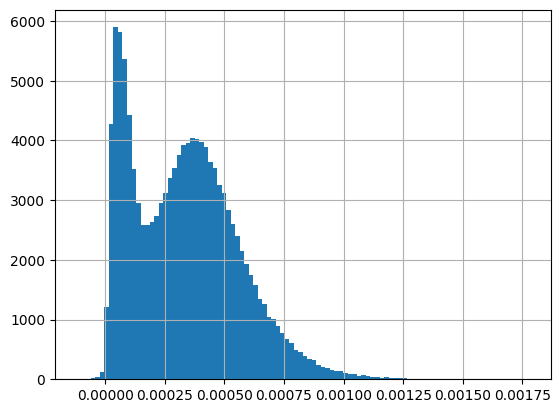

In [132]:
(
    baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates
).anemic_yld_rate.hist(bins=100)

In [133]:
zero_fort_scenario_ylds = (
    zero_fort_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  736.111714
                               2                  650.757670
                               3                  521.550200
                               4                  424.729902
                               5                  291.089988
                                                     ...    
Male    95.0       125.000000  1                   89.386189
                               2                   72.903842
                               3                   73.428445
                               4                   76.888359
                               5                   74.821911
Length: 250, dtype: float64

In [134]:
baseline_scenario_ylds = (
    baseline_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  736.111714
                               2                  650.757670
                               3                  521.550200
                               4                  424.729902
                               5                  291.089988
                                                     ...    
Male    95.0       125.000000  1                   89.386189
                               2                   72.903842
                               3                   73.428445
                               4                   76.888359
                               5                   74.821911
Length: 250, dtype: float64

In [135]:
intervention_scenarios_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_scenarios_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    730.590041
                               2                intervention    643.299827
                               3                intervention    513.014036
                               4                intervention    415.888615
                               5                intervention    283.116984
                                                                   ...    
Male    95.0       125.000000  1                intervention     88.683274
                               2                intervention     72.109468
                               3                intervention     72.457014
                               4                intervention     75.679461
                               5                intervention     73.490421
Length: 250, dtype: float64

In [136]:
(
    baseline_scenario_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_scenarios_ylds.loc[("Female", 25, 30, 1)].mean()
)

374.7805915654608

In [137]:
(
    baseline_scenario_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_scenarios_ylds.groupby(["scenario", "wealth_quintile"]).sum()
)

scenario      wealth_quintile
intervention  1                  11094.407273
              2                  13434.366701
              3                  14898.949300
              4                  16622.587836
              5                  14248.348076
dtype: float64

In [138]:
ylds = pd.concat(
    [
        zero_fort_scenario_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_scenario_ylds.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_scenarios_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,736.111714,zero
1,Female,0.0,0.019178,2,650.757670,zero
2,Female,0.0,0.019178,3,521.550200,zero
3,Female,0.0,0.019178,4,424.729902,zero
4,Female,0.0,0.019178,5,291.089988,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,88.683274,intervention
746,Male,95.0,125.000000,2,72.109468,intervention
747,Male,95.0,125.000000,3,72.457014,intervention
748,Male,95.0,125.000000,4,75.679461,intervention


In [139]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [140]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [141]:
zero_fort_anemia_prevalence = (
    zero_fort_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.900708
                               2                  0.876689
                               3                  0.835819
                               4                  0.828338
                               5                  0.748522
                                                    ...   
Male    95.0       125.000000  1                  0.910303
                               2                  0.899321
                               3                  0.890964
                               4                  0.891835
                               5                  0.880907
Length: 250, dtype: float64

In [142]:
baseline_anemia_prevalence = (
    baseline_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.900708
                               2                  0.876689
                               3                  0.835819
                               4                  0.828338
                               5                  0.748522
                                                    ...   
Male    95.0       125.000000  1                  0.910303
                               2                  0.899321
                               3                  0.890964
                               4                  0.891835
                               5                  0.880907
Length: 250, dtype: float64

In [143]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15276.458404
                               2                  14808.048479
                               3                  13328.773023
                               4                  11611.609394
                               5                   9753.105130
                                                      ...     
Male    95.0       125.000000  1                   1681.299915
                               2                   1453.600055
                               3                   1480.290163
                               4                   1586.629929
                               5                   1671.057535
Length: 250, dtype: float64

In [144]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.45867407015636424

In [145]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15276.458404
                               2                  14808.048479
                               3                  13328.773023
                               4                  11611.609394
                               5                   9753.105130
                                                      ...     
Male    95.0       125.000000  1                   1681.299915
                               2                   1453.600055
                               3                   1480.290163
                               4                   1586.629929
                               5                   1671.057535
Length: 250, dtype: float64

In [146]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.45867407015636424

In [147]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.556781
2    0.498840
3    0.454171
4    0.434832
5    0.350655
dtype: float64

In [148]:
intervention_anemia_prevalence = (
    intervention_scenarios_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.898466
                               2                intervention    0.872958
                               3                intervention    0.829967
                               4                intervention    0.820885
                               5                intervention    0.737737
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.908251
                               2                intervention    0.896152
                               3                intervention    0.886851
                               4                intervention    0.886954
                               5                intervention    0.874849
Length: 250, dtype: float64

In [149]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.900708,zero
1,Female,0.0,0.019178,2,0.876689,zero
2,Female,0.0,0.019178,3,0.835819,zero
3,Female,0.0,0.019178,4,0.828338,zero
4,Female,0.0,0.019178,5,0.748522,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.908251,intervention
746,Male,95.0,125.000000,2,0.896152,intervention
747,Male,95.0,125.000000,3,0.886851,intervention
748,Male,95.0,125.000000,4,0.886954,intervention


In [150]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [151]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    15238.433762
                               2                intervention    14745.030283
                               3                intervention    13235.442980
                               4                intervention    11507.129510
                               5                intervention     9612.572323
                                                                    ...     
Male    95.0       125.000000  1                intervention     1677.509876
                               2                intervention     1448.477068
                               3                intervention     1473.456386
                               4                intervention     1577.945920
                               5                intervention     1659.565678
Length: 250, dtype: float64

In [152]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.4511197801361123

In [153]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.551913
2    0.492310
3    0.446321
4    0.425646
5    0.341373
dtype: float64

In [154]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    215,544
2    290,687
3    351,059
4    414,759
5    417,148
dtype: object

In [155]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,15276.458404,zero
1,Female,0.0,0.019178,2,14808.048479,zero
2,Female,0.0,0.019178,3,13328.773023,zero
3,Female,0.0,0.019178,4,11611.609394,zero
4,Female,0.0,0.019178,5,9753.105130,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,1677.509876,intervention
746,Male,95.0,125.000000,2,1448.477068,intervention
747,Male,95.0,125.000000,3,1473.456386,intervention
748,Male,95.0,125.000000,4,1577.945920,intervention


In [156]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)